In [34]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")

import jaxsp as jsp

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from jaxsp.constants import GN, hbar

import Stellar_sim_funcs as SSF

from collections import defaultdict

from scipy.special import sph_harm_y


sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Tests/Testing_sim_methods")

import gaunt_funcs as gf

import s2fft

m22 = 1
u = jsp.set_schroedinger_units(m22)


In [35]:
def precompute_lm_pairs_Ylms(l):

    '''Precompute (l, m) pair for spherical harmonics'''

    lm_l = []      # list of l for each mode k
    lm_m = []      # list of m for each mode k
    parent_j = []  # which radial eigenstate j this (l,m) mode comes from
    lm_pairs = defaultdict(int)

    for j_idx, ell in enumerate(l.tolist()):
        for m in range(-ell, ell + 1):
            lm_l.append(ell)
            lm_m.append(m)
            parent_j.append(j_idx)
            lm_pairs[(ell, m)] += 1

    lm_pairs = list(lm_pairs.keys()) # list of ((l,m), count) pairs

    lm_pairs = jnp.array(lm_pairs)  # shape (Nmodes, 2)


    '''Precompute Y_lm's for wavefunction reconstruction'''

    # McEwen-Wiaux-style equiangular grid

    L = max(l)+1

    L_max_out = 2 * L - 1

    n_theta = L_max_out
    n_phi = 2 * L_max_out - 1

    # Generate theta values
    i = jnp.arange(n_theta)
    theta = (jnp.pi * (2 * i + 1)) / (2 * L_max_out - 1)
    # Generate phi values
    j = jnp.arange(n_phi)
    phi = (2 * jnp.pi * j) / (2 * L_max_out - 1)


    Theta, Phi = jnp.meshgrid(theta, phi, indexing="ij")  # both (n_theta, n_phi)

    Y_list = []
    for ell, m in zip(lm_l, lm_m):
        Y_lm_mode = sph_harm_y(ell, m, Theta, Phi)  # (n_theta, n_phi), complex
        Y_list.append(Y_lm_mode)

    Y_lm = jnp.stack(Y_list, axis=0)  # (Nmodes, n_theta, n_phi), complex


    return jnp.array(parent_j), Y_lm, lm_pairs, jnp.array(lm_l), jnp.array(lm_m), theta, phi

def _compute_all_phi(rho_lm, r, output_lm_pairs, L_max_out, G):
    """
    Vmapped computation of dphi_dr and phi_lm for all (l,m) pairs.
    All args are JAX arrays
    """
    Nr = rho_lm.shape[0] - 1
    dr     = jnp.diff(r)
    dr_rev = jnp.diff(r[::-1])

    def compute_phi_for_lm(lm_pair):
        l_val = lm_pair[0]
        m_val = lm_pair[1]
        prefix = -4.0 * jnp.pi * G / (2 * l_val + 1)
        m_ind  = m_val + L_max_out - 1

        f_at_lm = rho_lm[:, l_val, m_ind]

        integrand_ext = r ** (1 - l_val) * f_at_lm
        integrand_int = r ** (l_val + 2) * f_at_lm

        avg_int = 0.5 * (integrand_int[1:] + integrand_int[:-1])
        integral_int = jnp.concatenate([jnp.array([0.0]), jnp.cumsum(avg_int * dr)])


        integrand_ext_rev = integrand_ext[::-1]
        avg_ext = 0.5 * (integrand_ext_rev[1:] + integrand_ext_rev[:-1])
        integral_ext = jnp.concatenate([-jnp.cumsum(avg_ext * dr_rev)[::-1], jnp.array([0.0])])


        dphi_lm_dr = prefix * (l_val * r ** (l_val - 1) * integral_ext
                            - (l_val + 1) * r ** (-l_val - 2) * integral_int)
        phi_lm  = prefix * (r ** l_val * integral_ext
                            + r ** (-l_val - 1) * integral_int)
        return dphi_lm_dr, phi_lm

    return jax.vmap(compute_phi_for_lm)(output_lm_pairs)



cNFWtides_params = jnp.array([
357964808.148399 * u.from_Msun,
25.690207,
0.407461,
0.012670 * u.from_Kpc,
1.857991 * u.from_Kpc,
3.729259
])

density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

N = 512
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

N = 1024
a = 1
b = 10

rmax = jsp.enclosing_radius(0.99, density_params)
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)

l = eigenstate_lib.radial_eigenmode_params.l

eigen_energies = eigenstate_lib.radial_eigenmode_params.E


print('l max from jaxsp:', max(l))
L = int(max(l) + 1)


rmin = 20 * u.from_pc


tol = 1e-7
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)

total_mass = wavefunction_params.total_mass


aj_2 = wavefunction_params.aj_2        # shape (Nj,)


parent_j, Y_lm, lm_pairs, lm_l_per_mode, lm_m_per_mode, theta, phi = precompute_lm_pairs_Ylms(l)

lm_l = lm_pairs[:, 0]        # unique pairs — used for Gaunt table
lm_m = lm_pairs[:, 1]

Nmodes = len(parent_j)
rand_phase_per_mode = jax.random.uniform(jax.random.PRNGKey(42), shape=(Nmodes,), minval=0.0, maxval=2 * jnp.pi)
aj = jnp.sqrt(aj_2[parent_j]) * jnp.exp(1j * rand_phase_per_mode)  # shape (Nmodes,)




def construct_rho_lms(aj, parent_j, R_j_r_phased, lm_l, lm_m, total_mass, L_max_out, gaunt_table, scatter_matrix):

    # Use precomputed R_j_r_phased (set once per macro timestep in run_simulation)
    # to avoid recomputing exp(-i E t / hbar) on every call.
    R_modes = R_j_r_phased[:, parent_j]  # (Nr, Nmodes)
    aj_modes = aj  # already (Nmodes,) with independent phases


    rho_lm_gaunt = gf.compute_rho_lm_gaunt(
    aj_modes, R_modes, lm_l, lm_m, total_mass,
    L_max_out=L_max_out,
    gaunt_table=gaunt_table,
    scatter_matrix=scatter_matrix,
    )

    return rho_lm_gaunt

def forward_s2fft(rho_rtp, L_max_out):

    '''Forward s2fft of 3d density to get rho_lm(r)
    '''

    #Parallel forward SHT over all radii
    def forward_sht_single_r(rho_at_r):
        return s2fft.forward(rho_at_r, L_max_out, sampling='mw', method='jax')

    flm_r = jax.vmap(forward_sht_single_r)(rho_rtp)  # (Nr, L, 2*L-1)


    return flm_r


def construct_rho_rtp(R_j_r_phased, aj, parent_j, Y_lm):

    R_modes = R_j_r_phased[:, parent_j]  # (Nr, Nmodes)
    aj_modes = aj  # (Nmodes,) — already per-mode with independent phases

    full_psi_rtp = jnp.einsum('k,rk,ktp->rtp', aj_modes, R_modes, Y_lm)

    psi_abs2 = jnp.abs(full_psi_rtp) ** 2
    rho_rtp = total_mass * psi_abs2

    return rho_rtp


#print(f"Precomputation of (l,m) pairs and Y_lm grid completed in {end - start:.2f} seconds")

L_max_out = 2 * L - 1  # captures all density harmonics up to l1+l2 <= 2*(L-1)


# Precompute Gaunt table ONCE — reuse this across all time steps
gaunt_table = gf.precompute_gaunt_table(lm_l, lm_m, L_max_out)


_, _, _, _, unique_lm = gaunt_table
scatter_matrix = gf.make_scatter_matrix(lm_l_per_mode, lm_m_per_mode, unique_lm)




l max from jaxsp: 23
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...


In [ ]:
no_time_steps = 1000
total_evolve_time = 10
dt = (total_evolve_time * u.from_Gyr) / no_time_steps


In [36]:
no_bins = 1800

# r_truth is the 1800-bin grid used for phi_lm_2000
r_truth = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), no_bins)

print(f'Truth test using {no_bins} radius bins')
r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), int(no_bins))


R_j_r_fixed = eval_library(r, eigenstate_lib.radial_eigenmode_params)  # (Nr, Nj)


phase = jnp.exp(-1j * eigen_energies * 1 * dt / 1)
R_j_r_phased = R_j_r_fixed * phase[None, :]

out_lm = [(L, M) for L in range(L_max_out) for M in range(-L, L+1)]
output_lm_pairs = jnp.array(out_lm)


# 1. Construct total psi and rho on background grid
rho_lms = construct_rho_lms(aj, parent_j, R_j_r_phased, lm_l, lm_m, total_mass, L_max_out, gaunt_table, scatter_matrix)

print(rho_lms.shape)  # (Nr, L, 2L-1)

rho_rtp = construct_rho_rtp(R_j_r_phased, aj, parent_j, Y_lm)

rho_lms_s2fft = forward_s2fft(rho_rtp, L_max_out)


G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

dphi_lm_2000, phi_lm_2000 = _compute_all_phi(rho_lms, r, output_lm_pairs, int(L_max_out), G)


Truth test using 1800 radius bins
(1800, 47, 93)


[ 100.  185.  270.  355.  440.  525.  610.  695.  780.  865.  950. 1035.
 1120. 1205. 1290. 1375. 1460. 1545. 1630. 1715. 1800.]
No. radius bins: 100.0
(100, 47, 93)


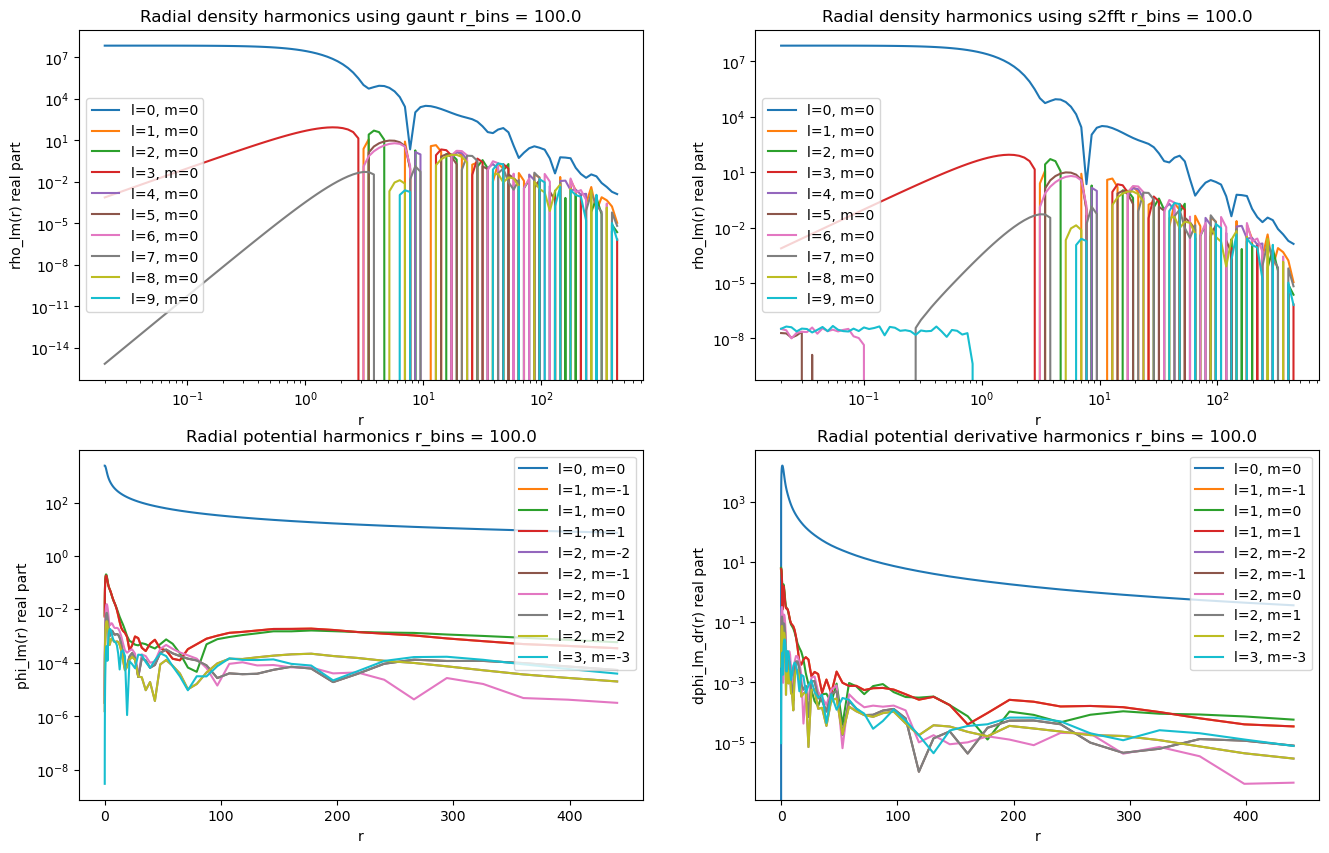

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.4247%
    l=1, m=-1: max err = 557.4447%
    l=1, m=0: max err = 183.2919%
    l=1, m=1: max err = 557.4447%
    l=2, m=-2: max err = 31.3957%
    l=2, m=-1: max err = 18.4616%
    l=2, m=0: max err = 1113.1362%
    l=2, m=1: max err = 18.4616%
    l=2, m=2: max err = 31.3957%
    l=3, m=-3: max err = 38.1137%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 8.6015%
    l=1, m=-1: max err = 569.2077%
    l=1, m=0: max err = 4090.4872%
    l=1, m=1: max err = 569.2077%
    l=2, m=-2: max err = 476.3556%
    l=2, m=-1: max err = 1933.8636%
    l=2, m=0: max err = 13454.7622%
    l=2, m=1: max err = 1933.8636%
    l=2, m=2: max err = 476.3556%
    l=3, m=-3: max err = 540.2962%
No. radius bins: 185.0
(185, 47, 93)


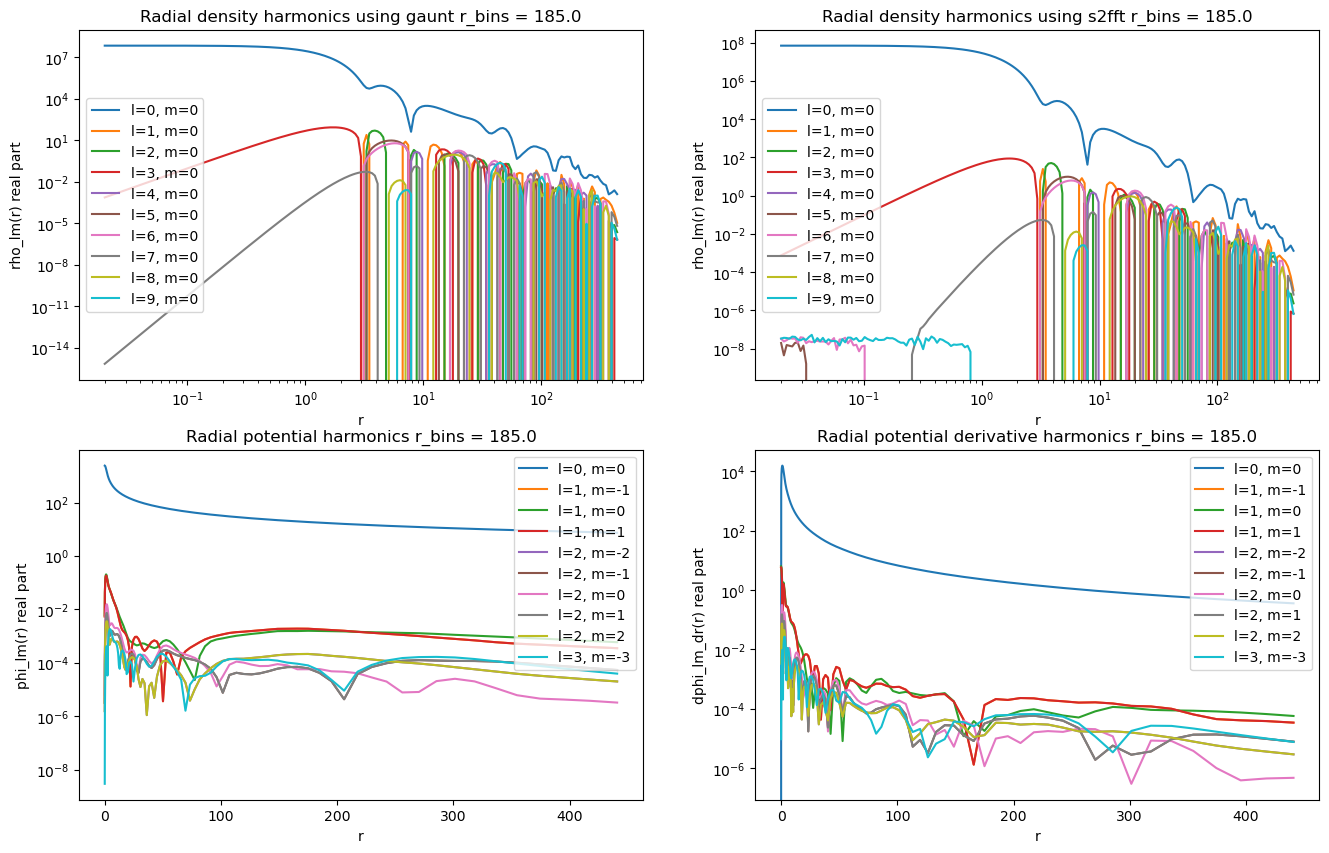

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.1219%
    l=1, m=-1: max err = 122.8502%
    l=1, m=0: max err = 25.9133%
    l=1, m=1: max err = 122.8502%
    l=2, m=-2: max err = 9.8331%
    l=2, m=-1: max err = 4.9631%
    l=2, m=0: max err = 287.9022%
    l=2, m=1: max err = 4.9631%
    l=2, m=2: max err = 9.8331%
    l=3, m=-3: max err = 10.0981%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 4.6017%
    l=1, m=-1: max err = 139.1831%
    l=1, m=0: max err = 1935.1620%
    l=1, m=1: max err = 139.1831%
    l=2, m=-2: max err = 341.4840%
    l=2, m=-1: max err = 562.3772%
    l=2, m=0: max err = 4338.1743%
    l=2, m=1: max err = 562.3772%
    l=2, m=2: max err = 341.4840%
    l=3, m=-3: max err = 188.0235%
No. radius bins: 270.0
(270, 47, 93)


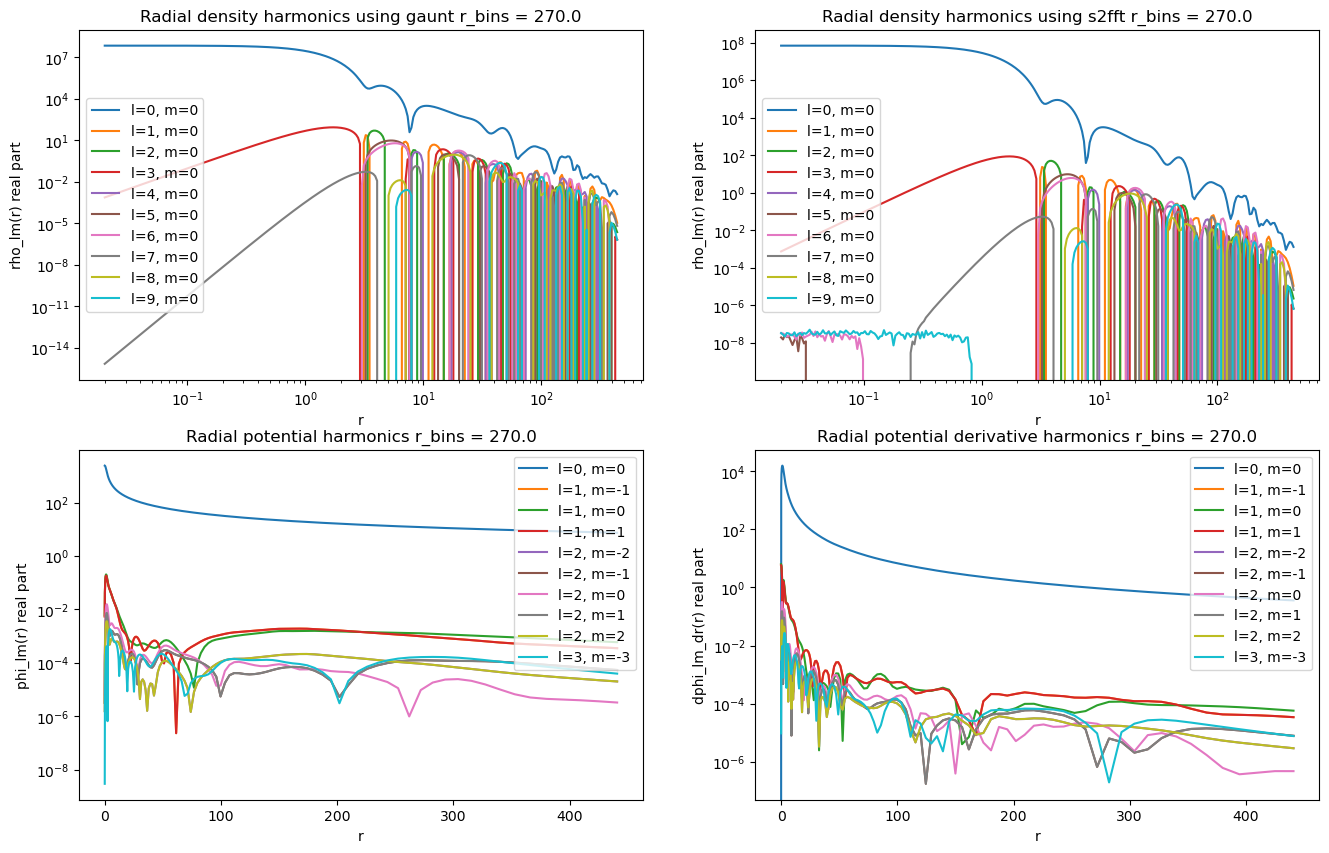

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0568%
    l=1, m=-1: max err = 57.5198%
    l=1, m=0: max err = 34.4542%
    l=1, m=1: max err = 57.5198%
    l=2, m=-2: max err = 3.9477%
    l=2, m=-1: max err = 2.7434%
    l=2, m=0: max err = 113.9070%
    l=2, m=1: max err = 2.7434%
    l=2, m=2: max err = 3.9477%
    l=3, m=-3: max err = 5.3186%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 3.0330%
    l=1, m=-1: max err = 79.3434%
    l=1, m=0: max err = 791.7290%
    l=1, m=1: max err = 79.3434%
    l=2, m=-2: max err = 183.5169%
    l=2, m=-1: max err = 233.8344%
    l=2, m=0: max err = 2036.7793%
    l=2, m=1: max err = 233.8344%
    l=2, m=2: max err = 183.5169%
    l=3, m=-3: max err = 60.0768%
No. radius bins: 355.0
(355, 47, 93)


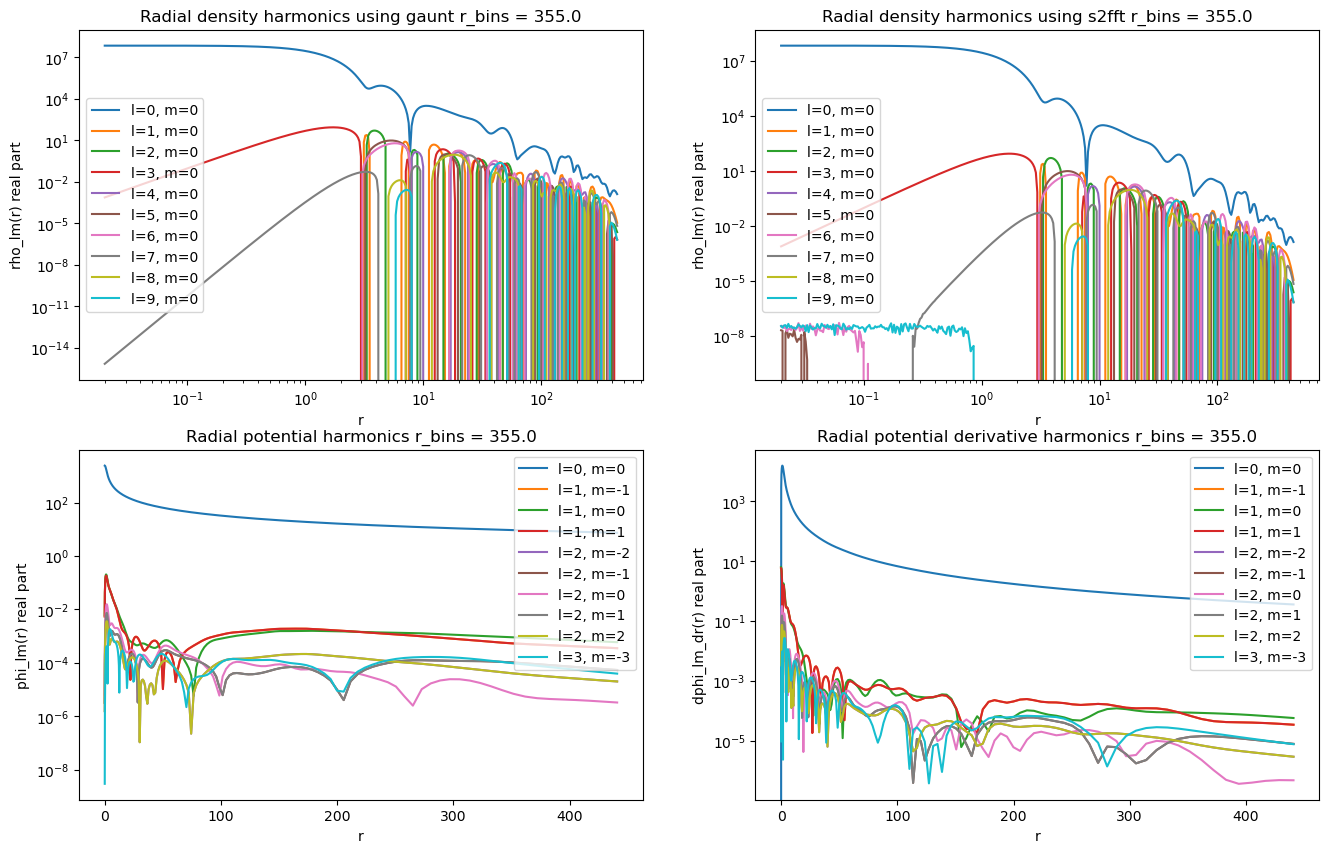

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0325%
    l=1, m=-1: max err = 20.0295%
    l=1, m=0: max err = 47.6521%
    l=1, m=1: max err = 20.0295%
    l=2, m=-2: max err = 2.6241%
    l=2, m=-1: max err = 1.6903%
    l=2, m=0: max err = 41.0573%
    l=2, m=1: max err = 1.6903%
    l=2, m=2: max err = 2.6241%
    l=3, m=-3: max err = 2.3511%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 2.1961%
    l=1, m=-1: max err = 51.9895%
    l=1, m=0: max err = 318.0238%
    l=1, m=1: max err = 51.9895%
    l=2, m=-2: max err = 110.9168%
    l=2, m=-1: max err = 111.3919%
    l=2, m=0: max err = 1318.6378%
    l=2, m=1: max err = 111.3919%
    l=2, m=2: max err = 110.9168%
    l=3, m=-3: max err = 30.7062%
No. radius bins: 440.0
(440, 47, 93)


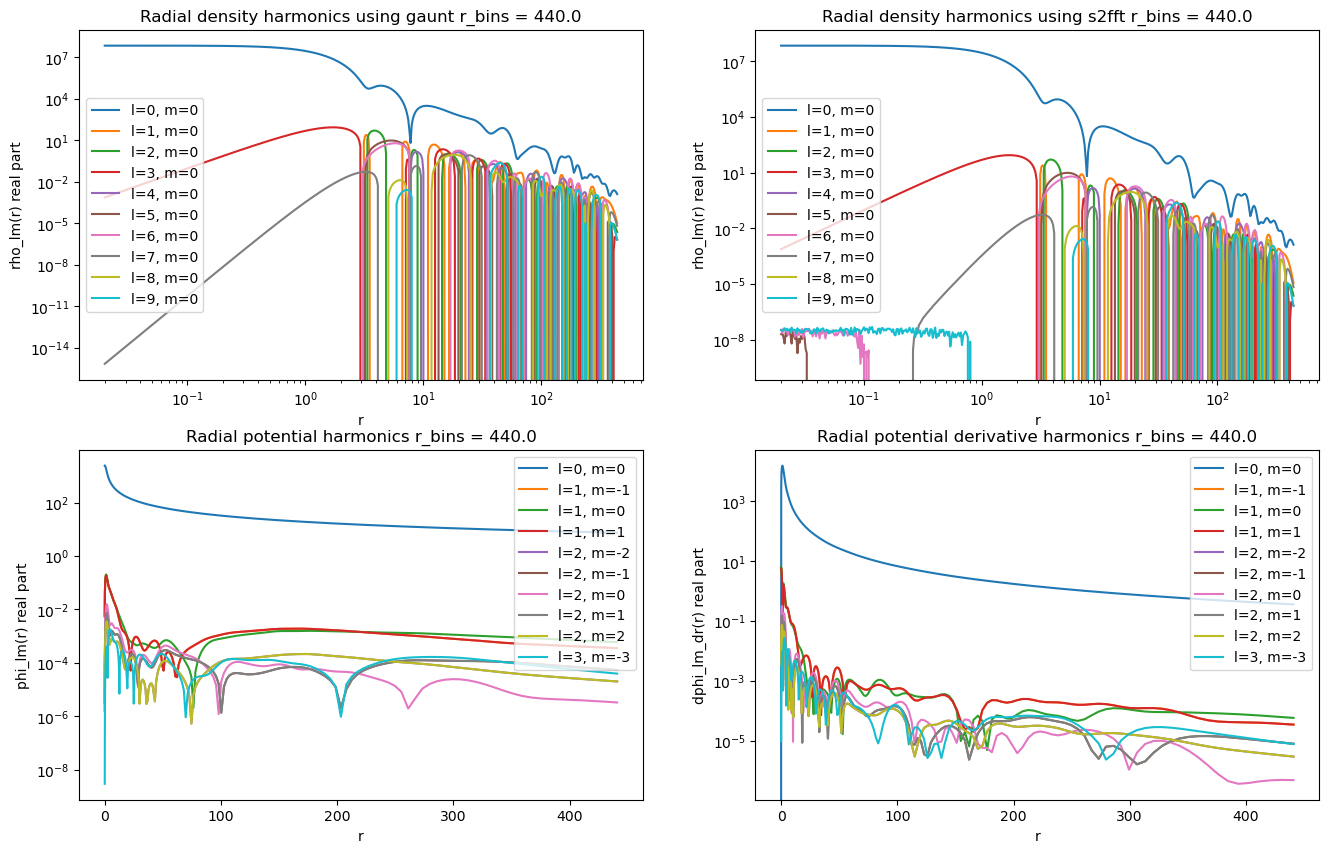

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0210%
    l=1, m=-1: max err = 20.5423%
    l=1, m=0: max err = 53.5230%
    l=1, m=1: max err = 20.5423%
    l=2, m=-2: max err = 1.3275%
    l=2, m=-1: max err = 1.2061%
    l=2, m=0: max err = 50.5519%
    l=2, m=1: max err = 1.2061%
    l=2, m=2: max err = 1.3275%
    l=3, m=-3: max err = 1.4541%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 1.6758%
    l=1, m=-1: max err = 33.8247%
    l=1, m=0: max err = 322.8353%
    l=1, m=1: max err = 33.8247%
    l=2, m=-2: max err = 73.2094%
    l=2, m=-1: max err = 53.7170%
    l=2, m=0: max err = 933.6403%
    l=2, m=1: max err = 53.7170%
    l=2, m=2: max err = 73.2094%
    l=3, m=-3: max err = 34.9376%
No. radius bins: 525.0
(525, 47, 93)


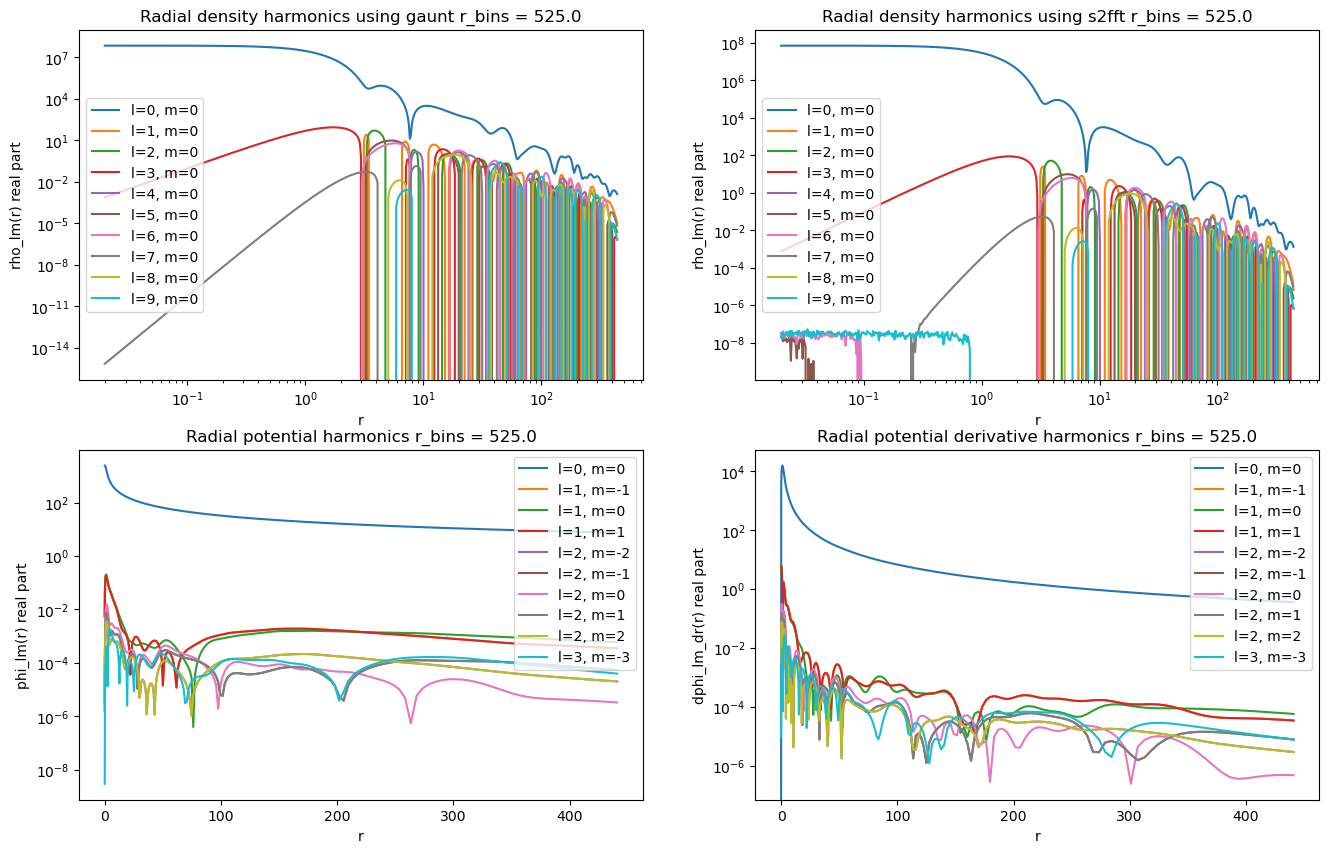

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0146%
    l=1, m=-1: max err = 10.3724%
    l=1, m=0: max err = 56.5906%
    l=1, m=1: max err = 10.3724%
    l=2, m=-2: max err = 0.9859%
    l=2, m=-1: max err = 0.7935%
    l=2, m=0: max err = 16.6084%
    l=2, m=1: max err = 0.7935%
    l=2, m=2: max err = 0.9859%
    l=3, m=-3: max err = 0.9903%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 1.3211%
    l=1, m=-1: max err = 22.8855%
    l=1, m=0: max err = 288.3239%
    l=1, m=1: max err = 22.8855%
    l=2, m=-2: max err = 51.3325%
    l=2, m=-1: max err = 33.1035%
    l=2, m=0: max err = 666.3113%
    l=2, m=1: max err = 33.1035%
    l=2, m=2: max err = 51.3325%
    l=3, m=-3: max err = 21.5037%
No. radius bins: 610.0
(610, 47, 93)


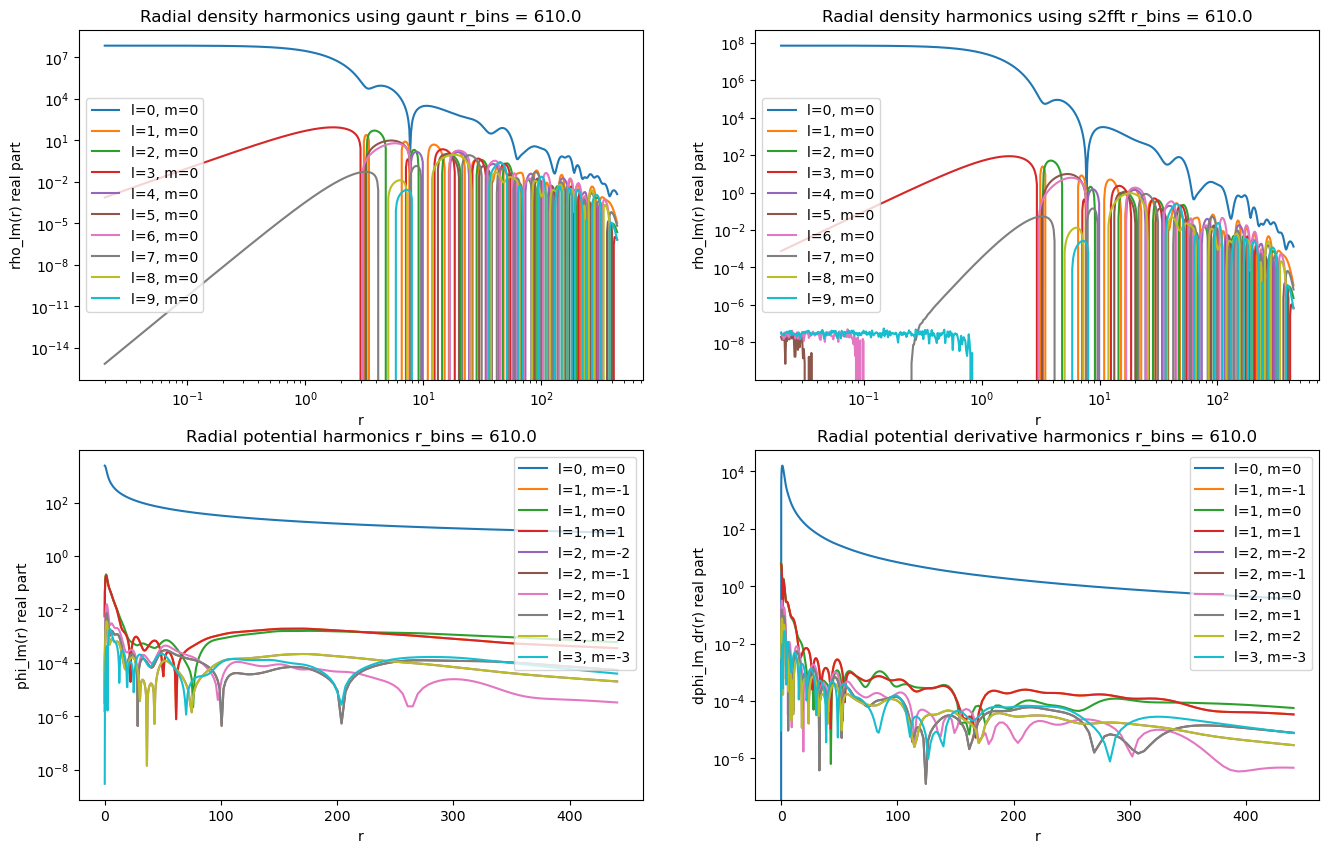

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0107%
    l=1, m=-1: max err = 10.1312%
    l=1, m=0: max err = 42.2409%
    l=1, m=1: max err = 10.1312%
    l=2, m=-2: max err = 0.8160%
    l=2, m=-1: max err = 0.6358%
    l=2, m=0: max err = 21.9849%
    l=2, m=1: max err = 0.6358%
    l=2, m=2: max err = 0.8160%
    l=3, m=-3: max err = 0.9480%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 1.0637%
    l=1, m=-1: max err = 15.8635%
    l=1, m=0: max err = 241.2676%
    l=1, m=1: max err = 15.8635%
    l=2, m=-2: max err = 37.5344%
    l=2, m=-1: max err = 32.9026%
    l=2, m=0: max err = 470.7026%
    l=2, m=1: max err = 32.9026%
    l=2, m=2: max err = 37.5344%
    l=3, m=-3: max err = 13.0980%
No. radius bins: 695.0
(695, 47, 93)


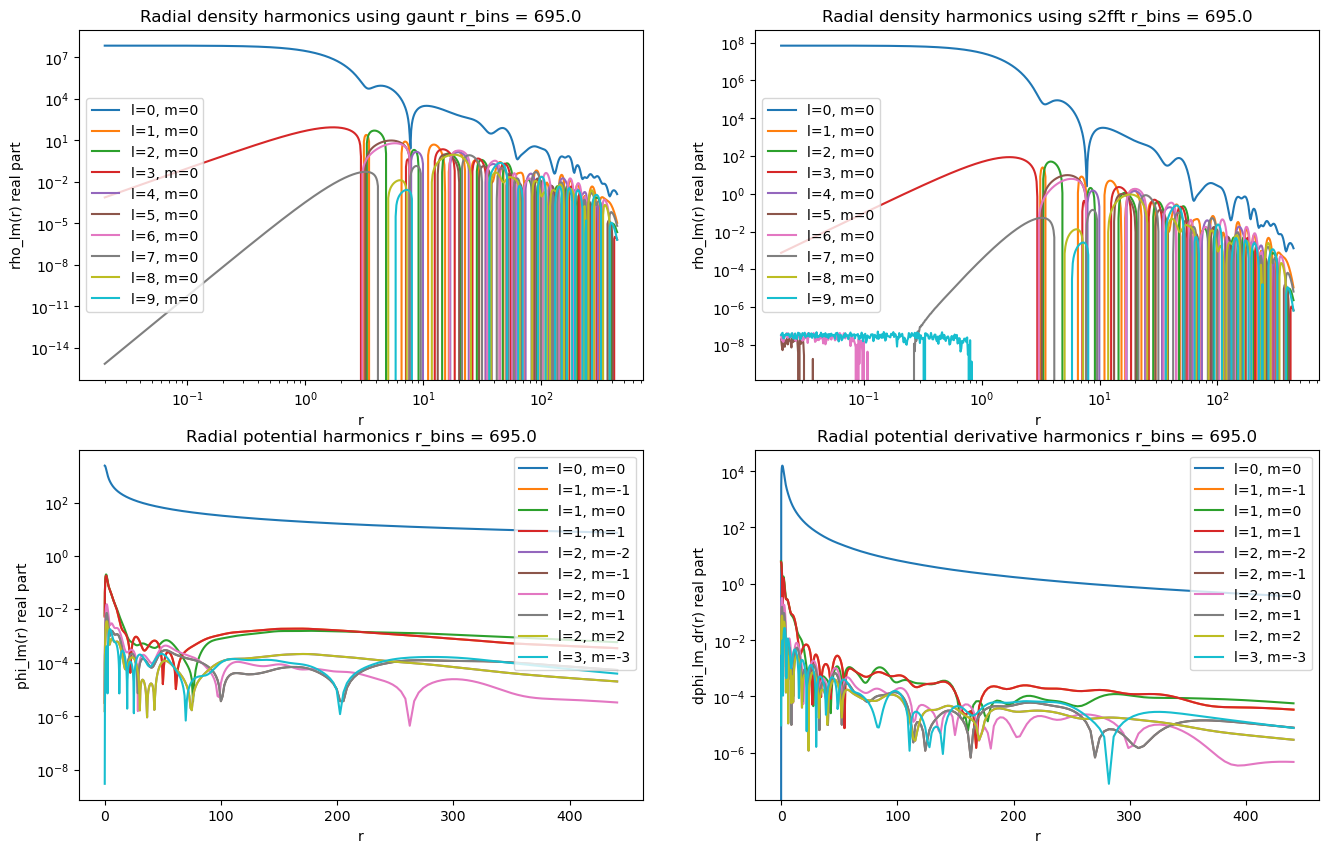

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0081%
    l=1, m=-1: max err = 5.9085%
    l=1, m=0: max err = 15.6404%
    l=1, m=1: max err = 5.9085%
    l=2, m=-2: max err = 0.5996%
    l=2, m=-1: max err = 0.4496%
    l=2, m=0: max err = 13.9178%
    l=2, m=1: max err = 0.4496%
    l=2, m=2: max err = 0.5996%
    l=3, m=-3: max err = 0.6744%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.8685%
    l=1, m=-1: max err = 13.8408%
    l=1, m=0: max err = 192.8734%
    l=1, m=1: max err = 13.8408%
    l=2, m=-2: max err = 28.2703%
    l=2, m=-1: max err = 30.9304%
    l=2, m=0: max err = 320.2759%
    l=2, m=1: max err = 30.9304%
    l=2, m=2: max err = 28.2703%
    l=3, m=-3: max err = 11.6753%
No. radius bins: 780.0
(780, 47, 93)


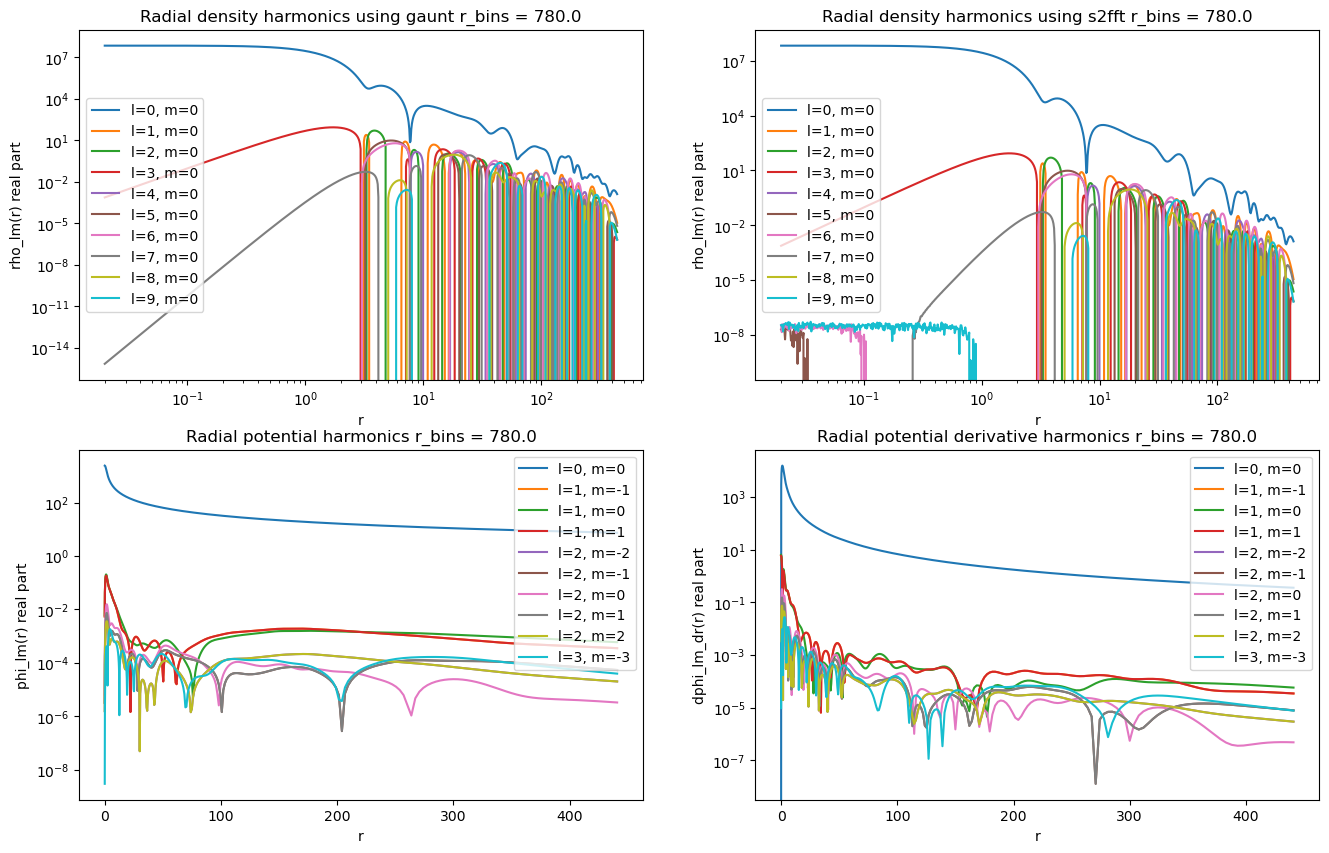

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0063%
    l=1, m=-1: max err = 5.7385%
    l=1, m=0: max err = 2.6827%
    l=1, m=1: max err = 5.7385%
    l=2, m=-2: max err = 0.5368%
    l=2, m=-1: max err = 0.3686%
    l=2, m=0: max err = 9.1770%
    l=2, m=1: max err = 0.3686%
    l=2, m=2: max err = 0.5368%
    l=3, m=-3: max err = 0.5254%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.7153%
    l=1, m=-1: max err = 10.2153%
    l=1, m=0: max err = 147.4305%
    l=1, m=1: max err = 10.2153%
    l=2, m=-2: max err = 21.7394%
    l=2, m=-1: max err = 28.1061%
    l=2, m=0: max err = 202.4124%
    l=2, m=1: max err = 28.1061%
    l=2, m=2: max err = 21.7394%
    l=3, m=-3: max err = 10.6103%
No. radius bins: 865.0
(865, 47, 93)


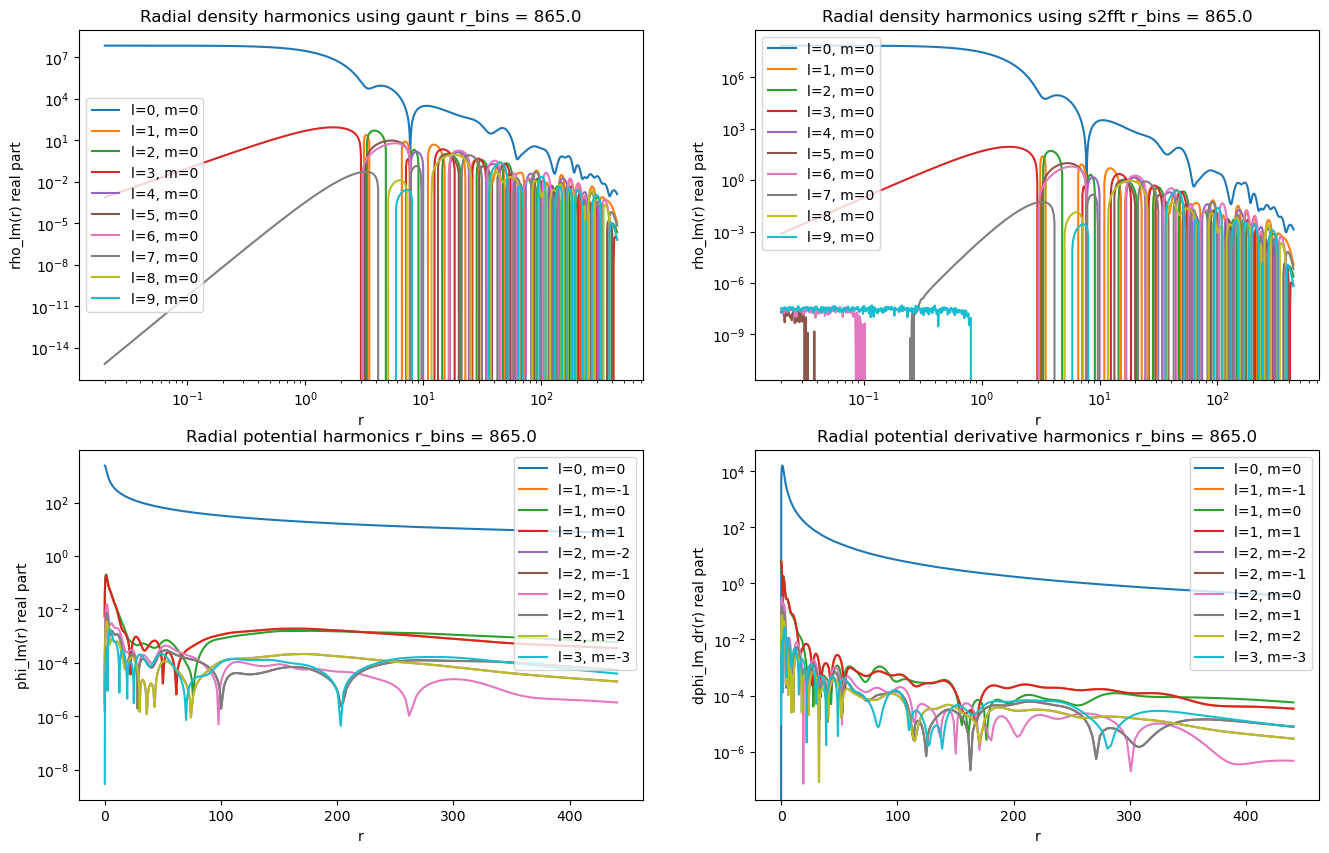

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0050%
    l=1, m=-1: max err = 3.6299%
    l=1, m=0: max err = 5.3722%
    l=1, m=1: max err = 3.6299%
    l=2, m=-2: max err = 0.4629%
    l=2, m=-1: max err = 0.2791%
    l=2, m=0: max err = 10.7724%
    l=2, m=1: max err = 0.2791%
    l=2, m=2: max err = 0.4629%
    l=3, m=-3: max err = 0.4571%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.5920%
    l=1, m=-1: max err = 8.2951%
    l=1, m=0: max err = 106.1494%
    l=1, m=1: max err = 8.2951%
    l=2, m=-2: max err = 16.9547%
    l=2, m=-1: max err = 25.0370%
    l=2, m=0: max err = 150.2252%
    l=2, m=1: max err = 25.0370%
    l=2, m=2: max err = 16.9547%
    l=3, m=-3: max err = 5.7381%
No. radius bins: 950.0
(950, 47, 93)


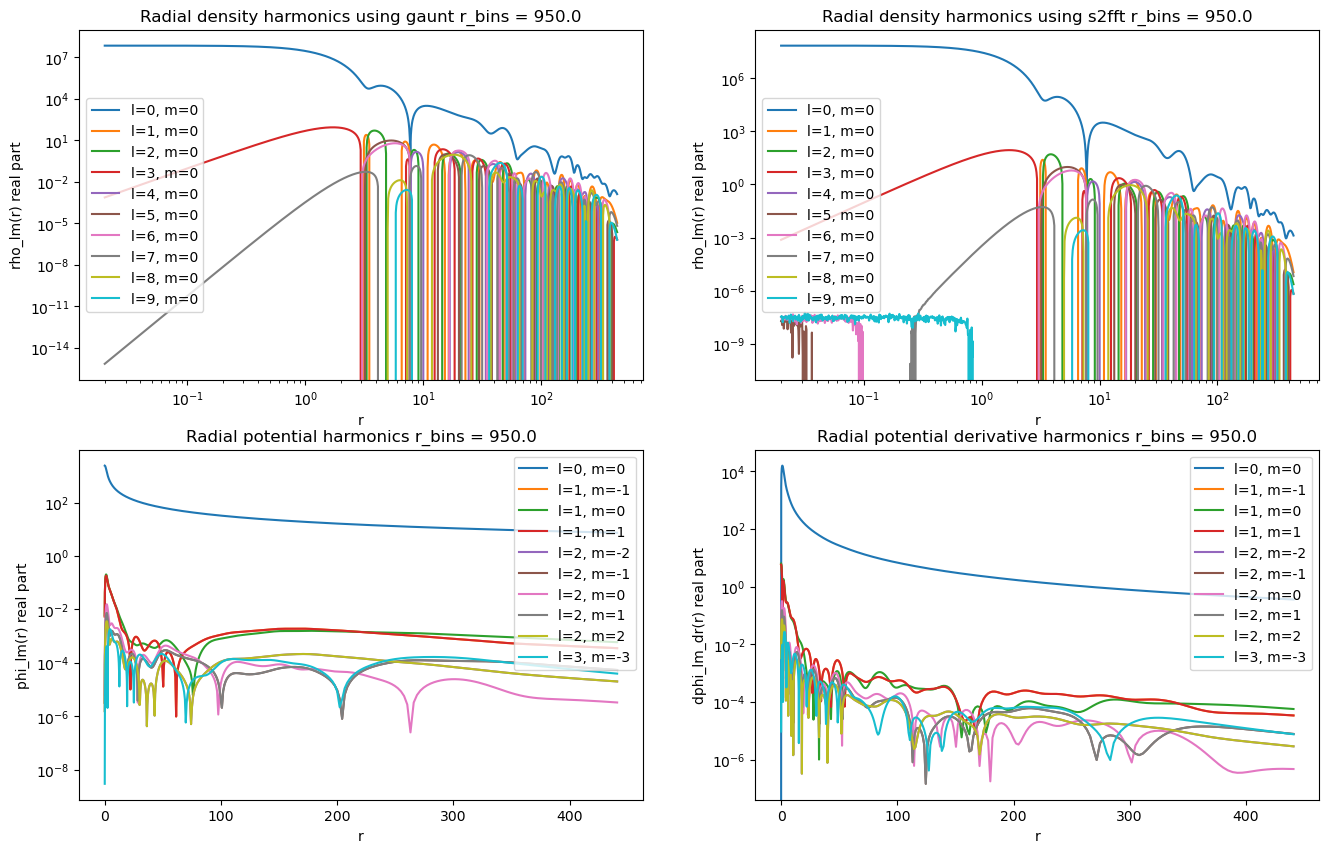

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0041%
    l=1, m=-1: max err = 3.4809%
    l=1, m=0: max err = 9.3605%
    l=1, m=1: max err = 3.4809%
    l=2, m=-2: max err = 0.3189%
    l=2, m=-1: max err = 0.2964%
    l=2, m=0: max err = 4.2108%
    l=2, m=1: max err = 0.2964%
    l=2, m=2: max err = 0.3189%
    l=3, m=-3: max err = 0.3986%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.4905%
    l=1, m=-1: max err = 6.4120%
    l=1, m=0: max err = 69.2478%
    l=1, m=1: max err = 6.4120%
    l=2, m=-2: max err = 13.3478%
    l=2, m=-1: max err = 21.9648%
    l=2, m=0: max err = 116.1904%
    l=2, m=1: max err = 21.9648%
    l=2, m=2: max err = 13.3478%
    l=3, m=-3: max err = 3.9566%
No. radius bins: 1035.0
(1035, 47, 93)


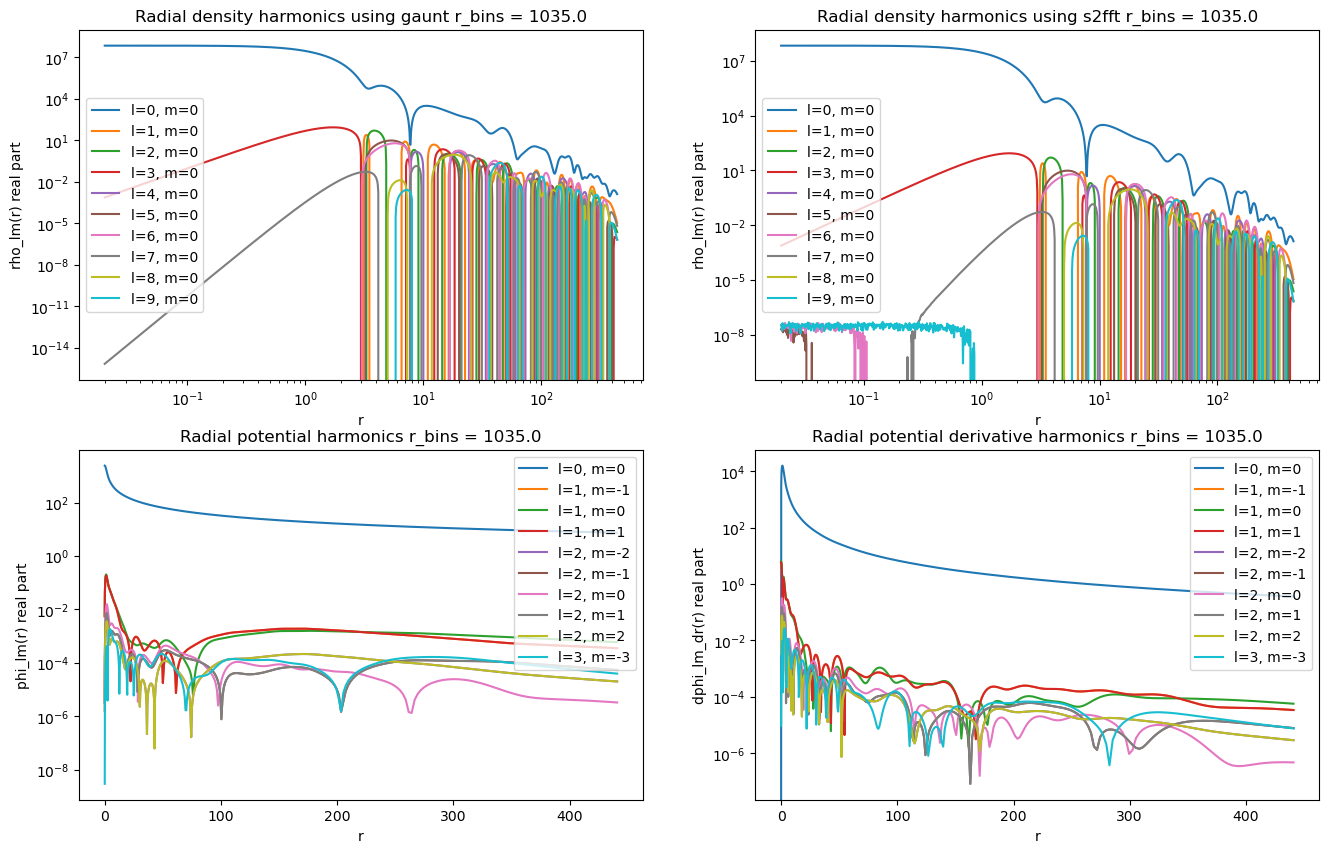

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0034%
    l=1, m=-1: max err = 3.7497%
    l=1, m=0: max err = 11.1538%
    l=1, m=1: max err = 3.7497%
    l=2, m=-2: max err = 0.3240%
    l=2, m=-1: max err = 0.2382%
    l=2, m=0: max err = 6.6085%
    l=2, m=1: max err = 0.2382%
    l=2, m=2: max err = 0.3240%
    l=3, m=-3: max err = 0.3311%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.4055%
    l=1, m=-1: max err = 5.6957%
    l=1, m=0: max err = 36.3409%
    l=1, m=1: max err = 5.6957%
    l=2, m=-2: max err = 10.5410%
    l=2, m=-1: max err = 19.0073%
    l=2, m=0: max err = 91.2564%
    l=2, m=1: max err = 19.0073%
    l=2, m=2: max err = 10.5410%
    l=3, m=-3: max err = 5.7050%
No. radius bins: 1120.0
(1120, 47, 93)


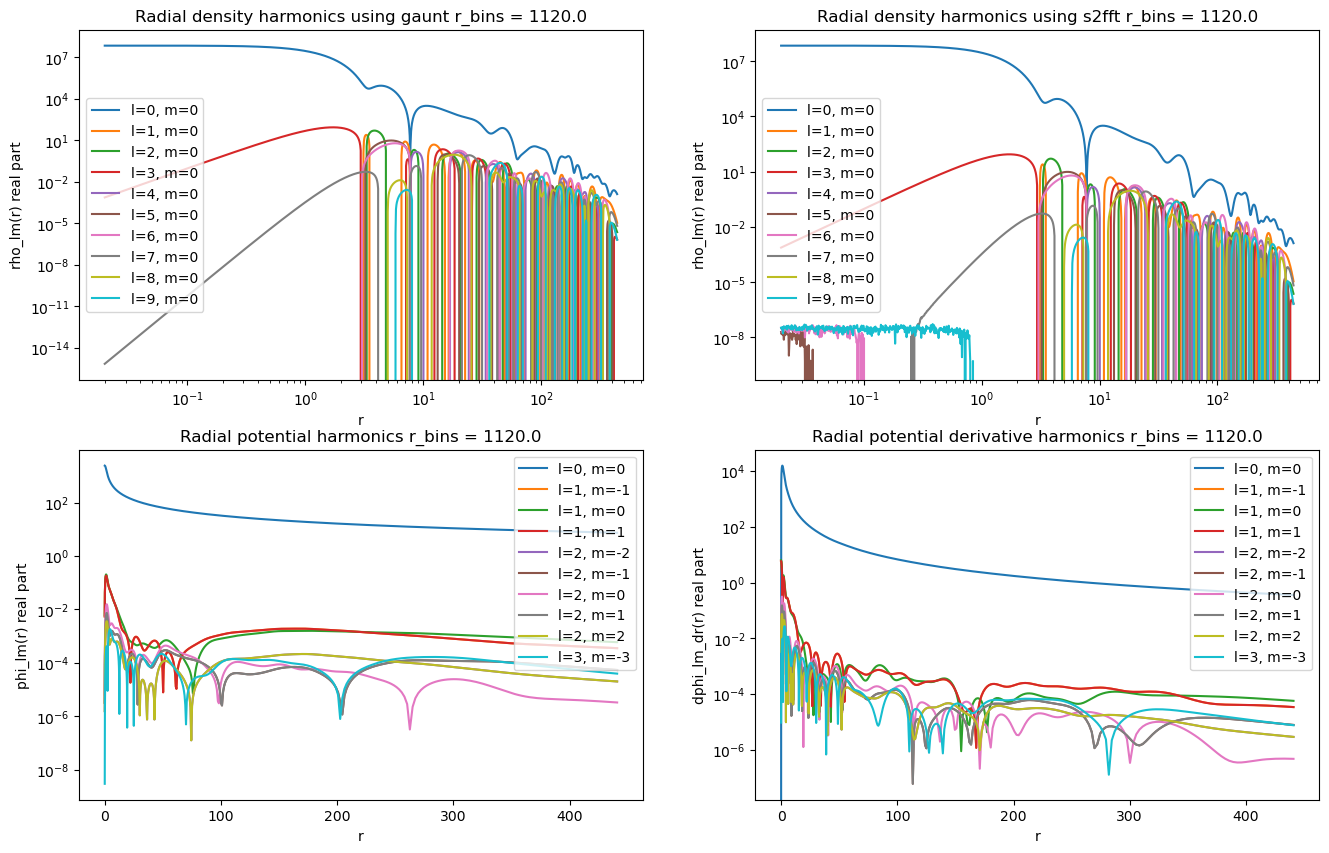

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0028%
    l=1, m=-1: max err = 2.1486%
    l=1, m=0: max err = 11.3674%
    l=1, m=1: max err = 2.1486%
    l=2, m=-2: max err = 0.3036%
    l=2, m=-1: max err = 0.2107%
    l=2, m=0: max err = 4.8576%
    l=2, m=1: max err = 0.2107%
    l=2, m=2: max err = 0.3036%
    l=3, m=-3: max err = 0.3222%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.3333%
    l=1, m=-1: max err = 4.2723%
    l=1, m=0: max err = 30.5919%
    l=1, m=1: max err = 4.2723%
    l=2, m=-2: max err = 8.3237%
    l=2, m=-1: max err = 16.2184%
    l=2, m=0: max err = 99.0428%
    l=2, m=1: max err = 16.2184%
    l=2, m=2: max err = 8.3237%
    l=3, m=-3: max err = 4.1950%
No. radius bins: 1205.0
(1205, 47, 93)


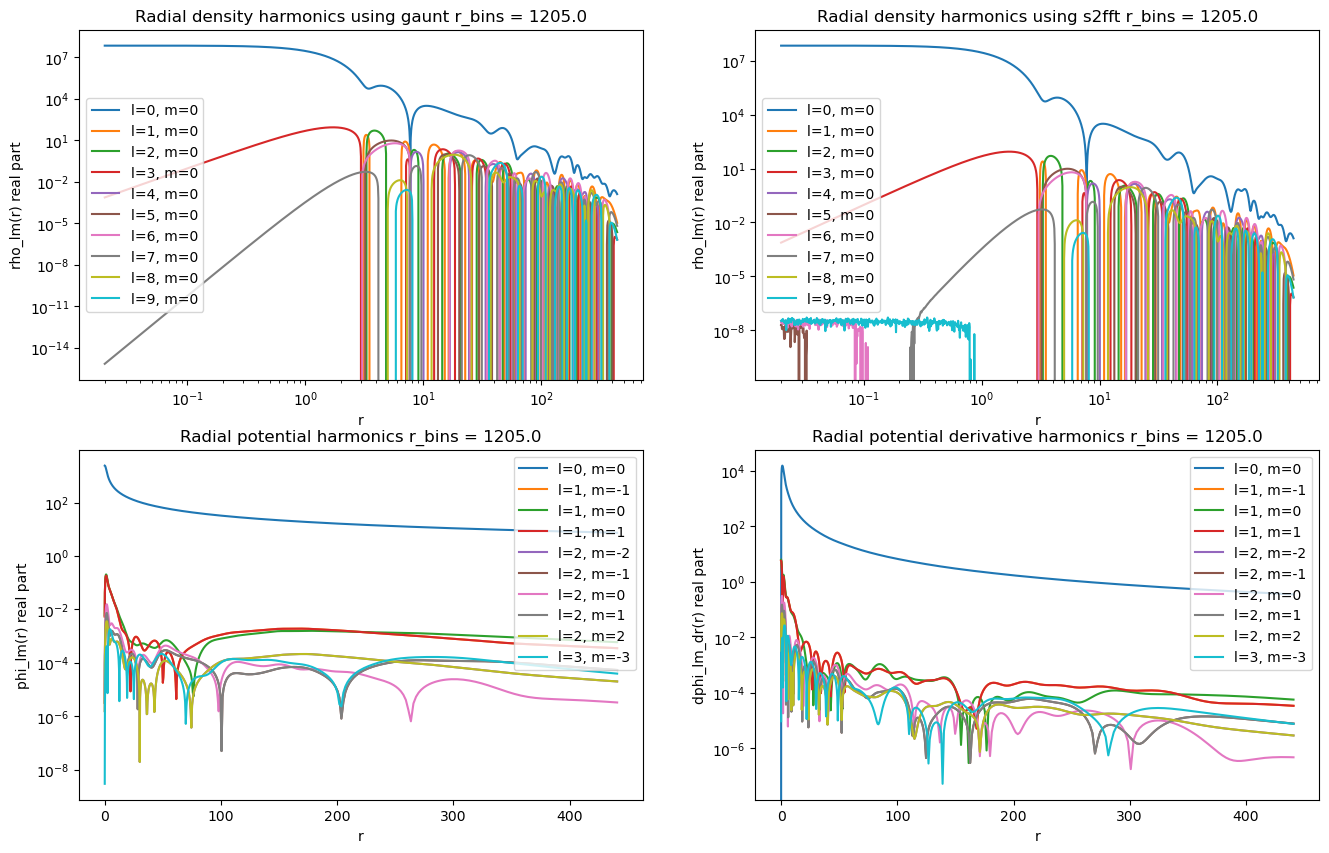

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0023%
    l=1, m=-1: max err = 3.5802%
    l=1, m=0: max err = 10.7183%
    l=1, m=1: max err = 3.5802%
    l=2, m=-2: max err = 0.2700%
    l=2, m=-1: max err = 0.1807%
    l=2, m=0: max err = 2.8636%
    l=2, m=1: max err = 0.1807%
    l=2, m=2: max err = 0.2700%
    l=3, m=-3: max err = 0.3031%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.2712%
    l=1, m=-1: max err = 3.9172%
    l=1, m=0: max err = 39.6876%
    l=1, m=1: max err = 3.9172%
    l=2, m=-2: max err = 6.5363%
    l=2, m=-1: max err = 13.6103%
    l=2, m=0: max err = 98.0933%
    l=2, m=1: max err = 13.6103%
    l=2, m=2: max err = 6.5363%
    l=3, m=-3: max err = 2.3757%
No. radius bins: 1290.0
(1290, 47, 93)


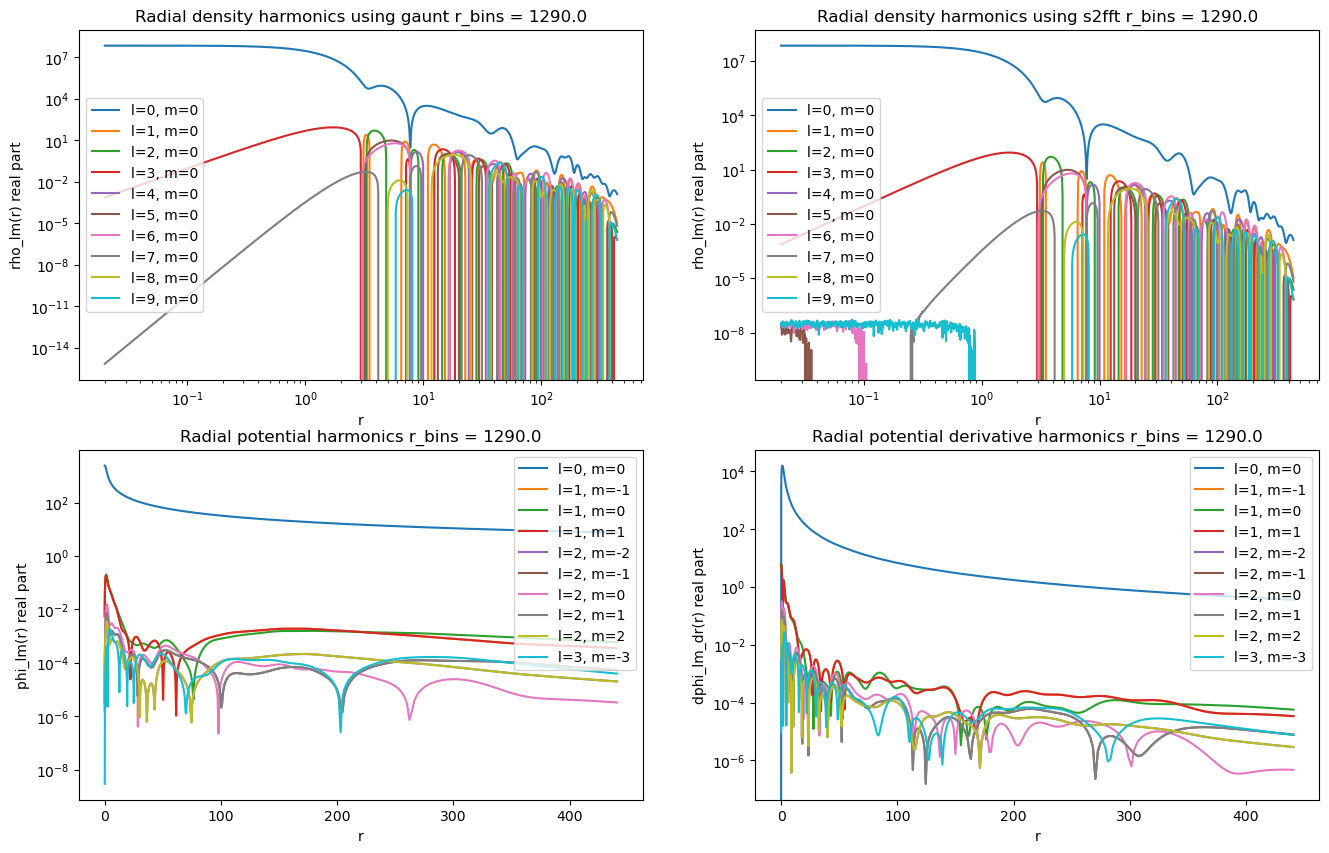

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0020%
    l=1, m=-1: max err = 1.3452%
    l=1, m=0: max err = 9.7150%
    l=1, m=1: max err = 1.3452%
    l=2, m=-2: max err = 0.2606%
    l=2, m=-1: max err = 0.1678%
    l=2, m=0: max err = 3.5901%
    l=2, m=1: max err = 0.1678%
    l=2, m=2: max err = 0.2606%
    l=3, m=-3: max err = 0.2698%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.2173%
    l=1, m=-1: max err = 3.3022%
    l=1, m=0: max err = 42.0425%
    l=1, m=1: max err = 3.3022%
    l=2, m=-2: max err = 5.0682%
    l=2, m=-1: max err = 11.1965%
    l=2, m=0: max err = 91.2381%
    l=2, m=1: max err = 11.1965%
    l=2, m=2: max err = 5.0682%
    l=3, m=-3: max err = 2.9531%
No. radius bins: 1375.0
(1375, 47, 93)


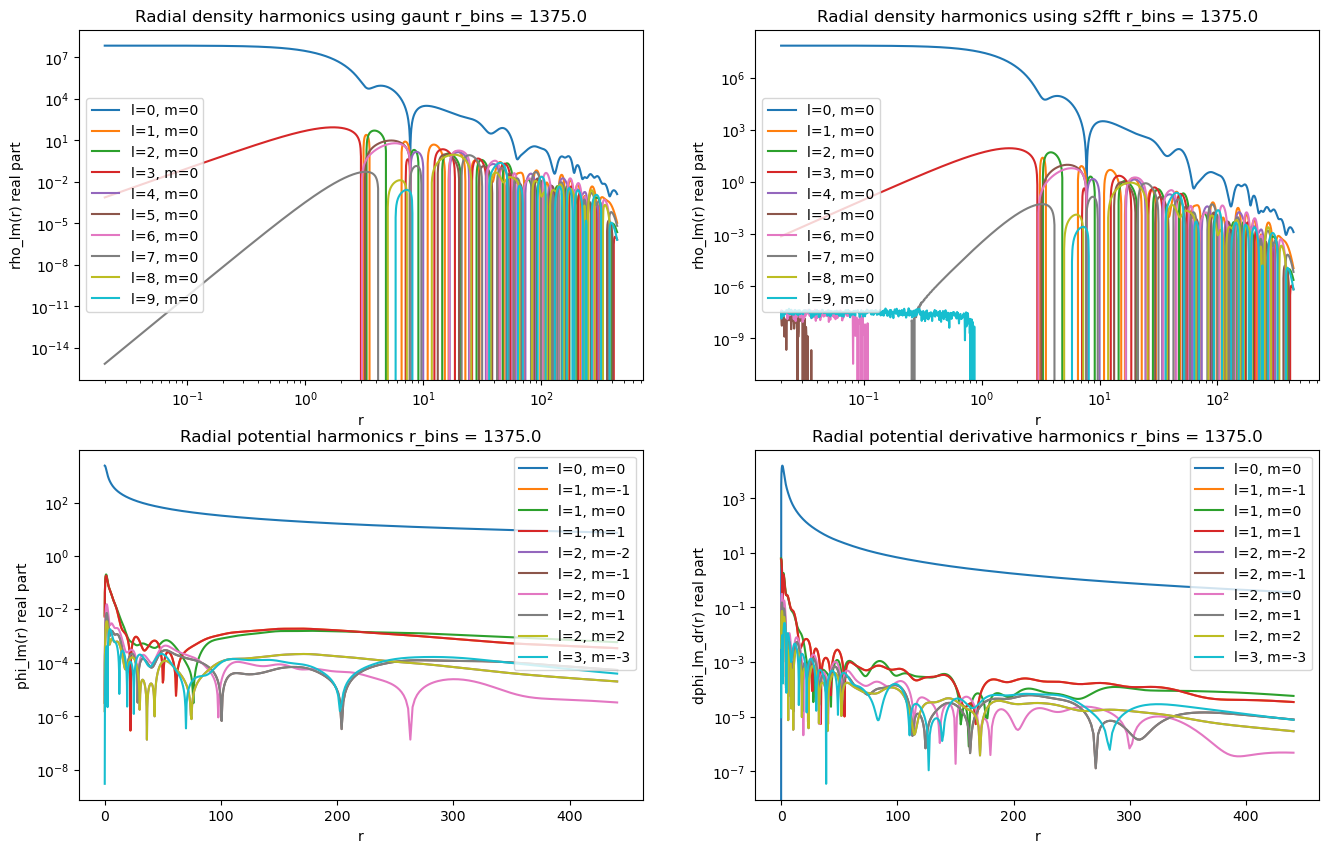

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0017%
    l=1, m=-1: max err = 3.3307%
    l=1, m=0: max err = 8.2698%
    l=1, m=1: max err = 3.3307%
    l=2, m=-2: max err = 0.2321%
    l=2, m=-1: max err = 0.1689%
    l=2, m=0: max err = 1.2045%
    l=2, m=1: max err = 0.1689%
    l=2, m=2: max err = 0.2321%
    l=3, m=-3: max err = 0.2546%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.1699%
    l=1, m=-1: max err = 2.6829%
    l=1, m=0: max err = 39.8682%
    l=1, m=1: max err = 2.6829%
    l=2, m=-2: max err = 4.1173%
    l=2, m=-1: max err = 8.9598%
    l=2, m=0: max err = 80.2699%
    l=2, m=1: max err = 8.9598%
    l=2, m=2: max err = 4.1173%
    l=3, m=-3: max err = 2.9276%
No. radius bins: 1460.0
(1460, 47, 93)


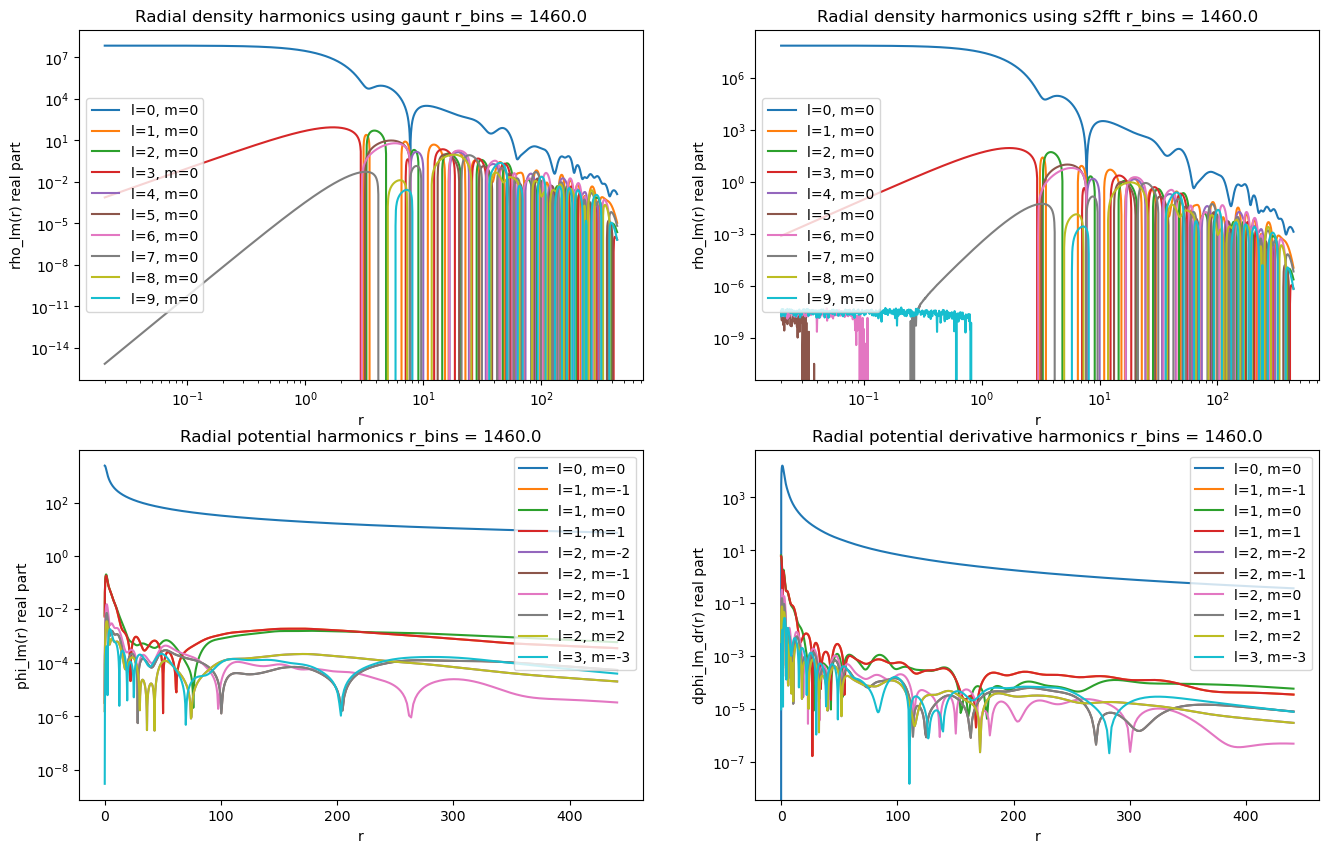

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0014%
    l=1, m=-1: max err = 0.8362%
    l=1, m=0: max err = 6.6863%
    l=1, m=1: max err = 0.8362%
    l=2, m=-2: max err = 0.2323%
    l=2, m=-1: max err = 0.1529%
    l=2, m=0: max err = 2.5430%
    l=2, m=1: max err = 0.1529%
    l=2, m=2: max err = 0.2323%
    l=3, m=-3: max err = 0.2410%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.1281%
    l=1, m=-1: max err = 2.1053%
    l=1, m=0: max err = 34.6584%
    l=1, m=1: max err = 2.1053%
    l=2, m=-2: max err = 3.2370%
    l=2, m=-1: max err = 6.8880%
    l=2, m=0: max err = 66.5767%
    l=2, m=1: max err = 6.8880%
    l=2, m=2: max err = 3.2370%
    l=3, m=-3: max err = 1.5677%
No. radius bins: 1545.0
(1545, 47, 93)


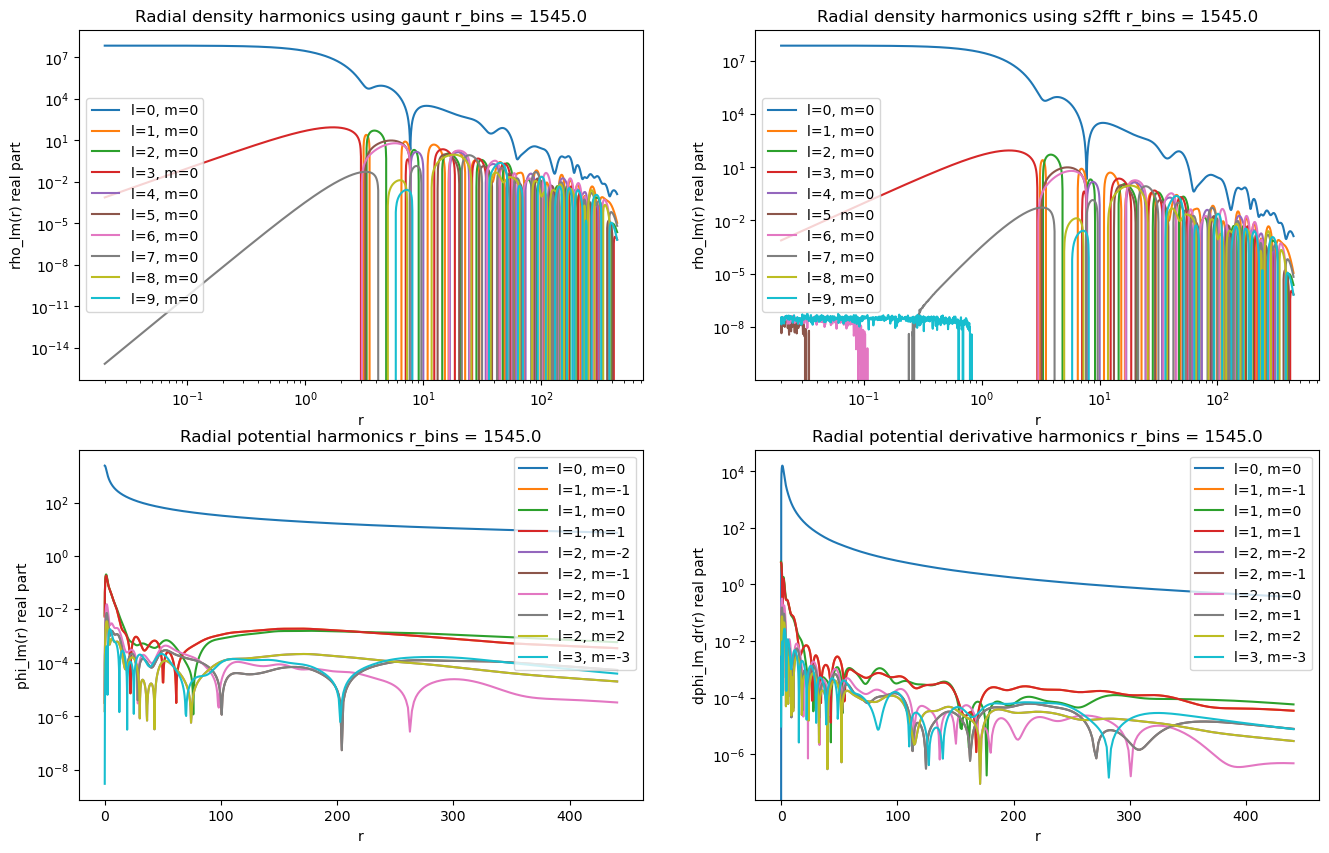

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0012%
    l=1, m=-1: max err = 3.0540%
    l=1, m=0: max err = 5.0181%
    l=1, m=1: max err = 3.0540%
    l=2, m=-2: max err = 0.2127%
    l=2, m=-1: max err = 0.1437%
    l=2, m=0: max err = 2.5854%
    l=2, m=1: max err = 0.1437%
    l=2, m=2: max err = 0.2127%
    l=3, m=-3: max err = 0.2059%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.0908%
    l=1, m=-1: max err = 1.9825%
    l=1, m=0: max err = 27.4614%
    l=1, m=1: max err = 1.9825%
    l=2, m=-2: max err = 2.3783%
    l=2, m=-1: max err = 4.9684%
    l=2, m=0: max err = 51.1146%
    l=2, m=1: max err = 4.9684%
    l=2, m=2: max err = 2.3783%
    l=3, m=-3: max err = 1.5845%
No. radius bins: 1630.0
(1630, 47, 93)


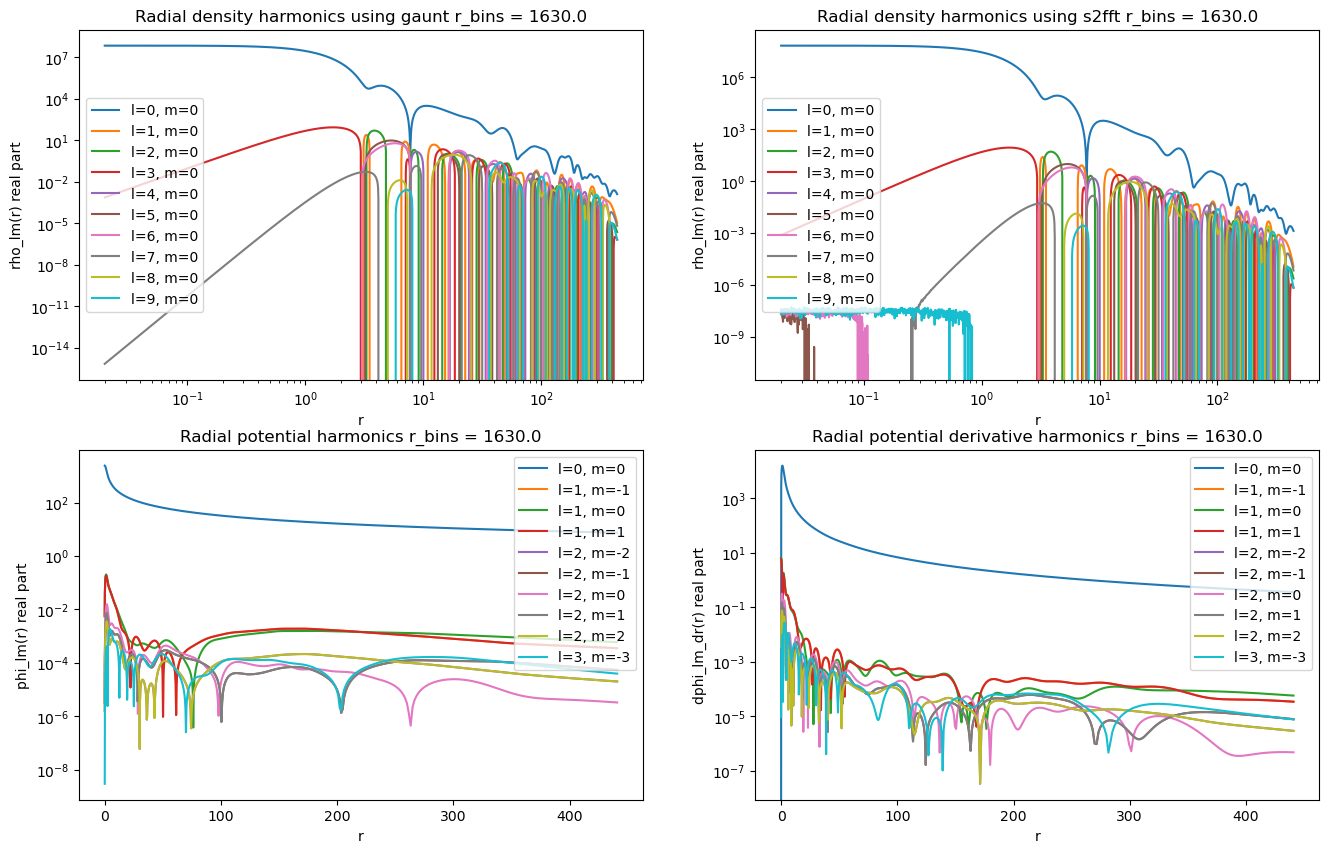

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0011%
    l=1, m=-1: max err = 0.3879%
    l=1, m=0: max err = 3.3609%
    l=1, m=1: max err = 0.3879%
    l=2, m=-2: max err = 0.1881%
    l=2, m=-1: max err = 0.1155%
    l=2, m=0: max err = 2.5062%
    l=2, m=1: max err = 0.1155%
    l=2, m=2: max err = 0.1881%
    l=3, m=-3: max err = 0.2144%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.0574%
    l=1, m=-1: max err = 1.8027%
    l=1, m=0: max err = 18.9776%
    l=1, m=1: max err = 1.8027%
    l=2, m=-2: max err = 1.5503%
    l=2, m=-1: max err = 3.1891%
    l=2, m=0: max err = 34.5634%
    l=2, m=1: max err = 3.1891%
    l=2, m=2: max err = 1.5503%
    l=3, m=-3: max err = 1.9005%
No. radius bins: 1715.0
(1715, 47, 93)


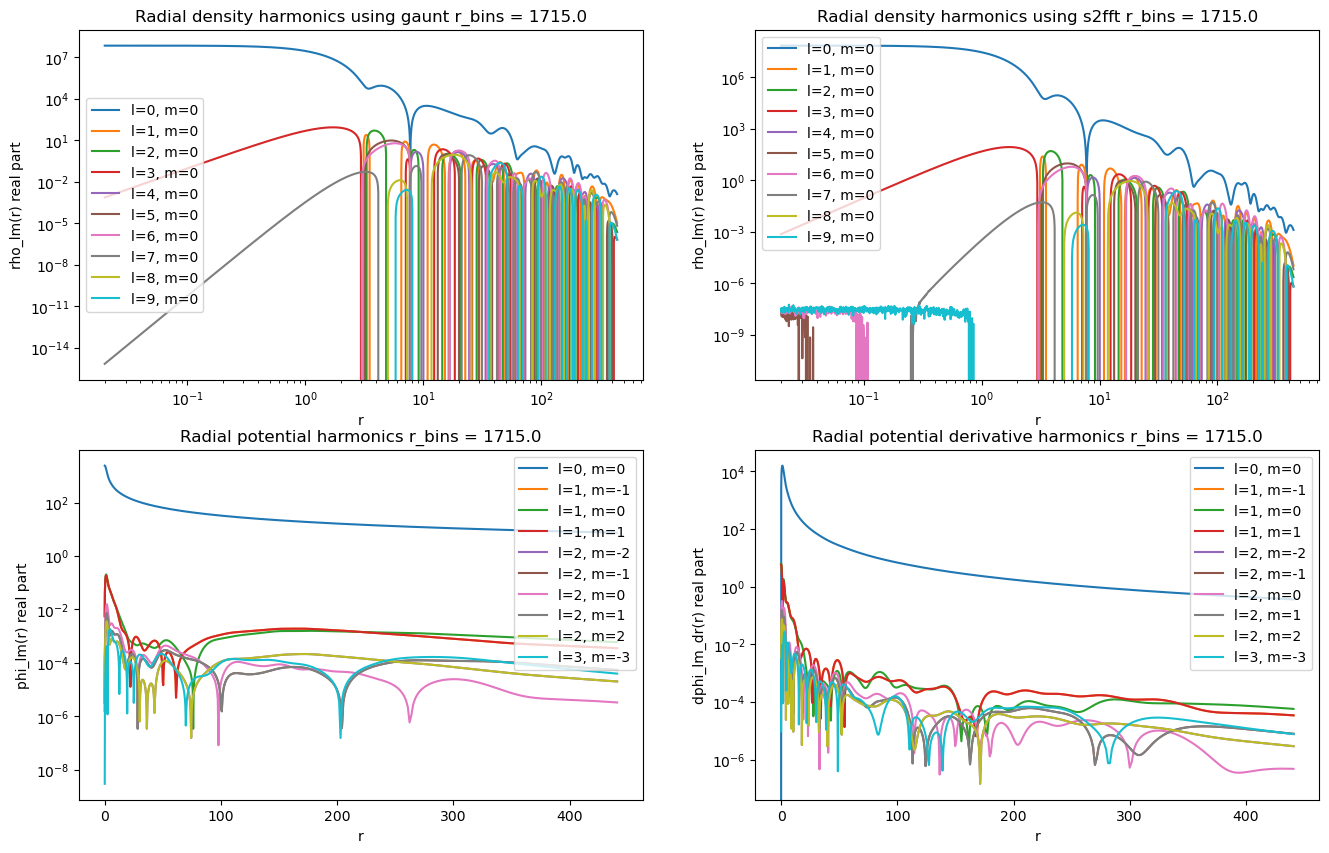

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0009%
    l=1, m=-1: max err = 2.7863%
    l=1, m=0: max err = 1.6632%
    l=1, m=1: max err = 2.7863%
    l=2, m=-2: max err = 0.1327%
    l=2, m=-1: max err = 0.0823%
    l=2, m=0: max err = 1.6862%
    l=2, m=1: max err = 0.0823%
    l=2, m=2: max err = 0.1327%
    l=3, m=-3: max err = 0.2047%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.0273%
    l=1, m=-1: max err = 1.2452%
    l=1, m=0: max err = 10.0712%
    l=1, m=1: max err = 1.2452%
    l=2, m=-2: max err = 1.1956%
    l=2, m=-1: max err = 1.6174%
    l=2, m=0: max err = 17.4146%
    l=2, m=1: max err = 1.6174%
    l=2, m=2: max err = 1.1956%
    l=3, m=-3: max err = 1.3408%
No. radius bins: 1800.0
(1800, 47, 93)


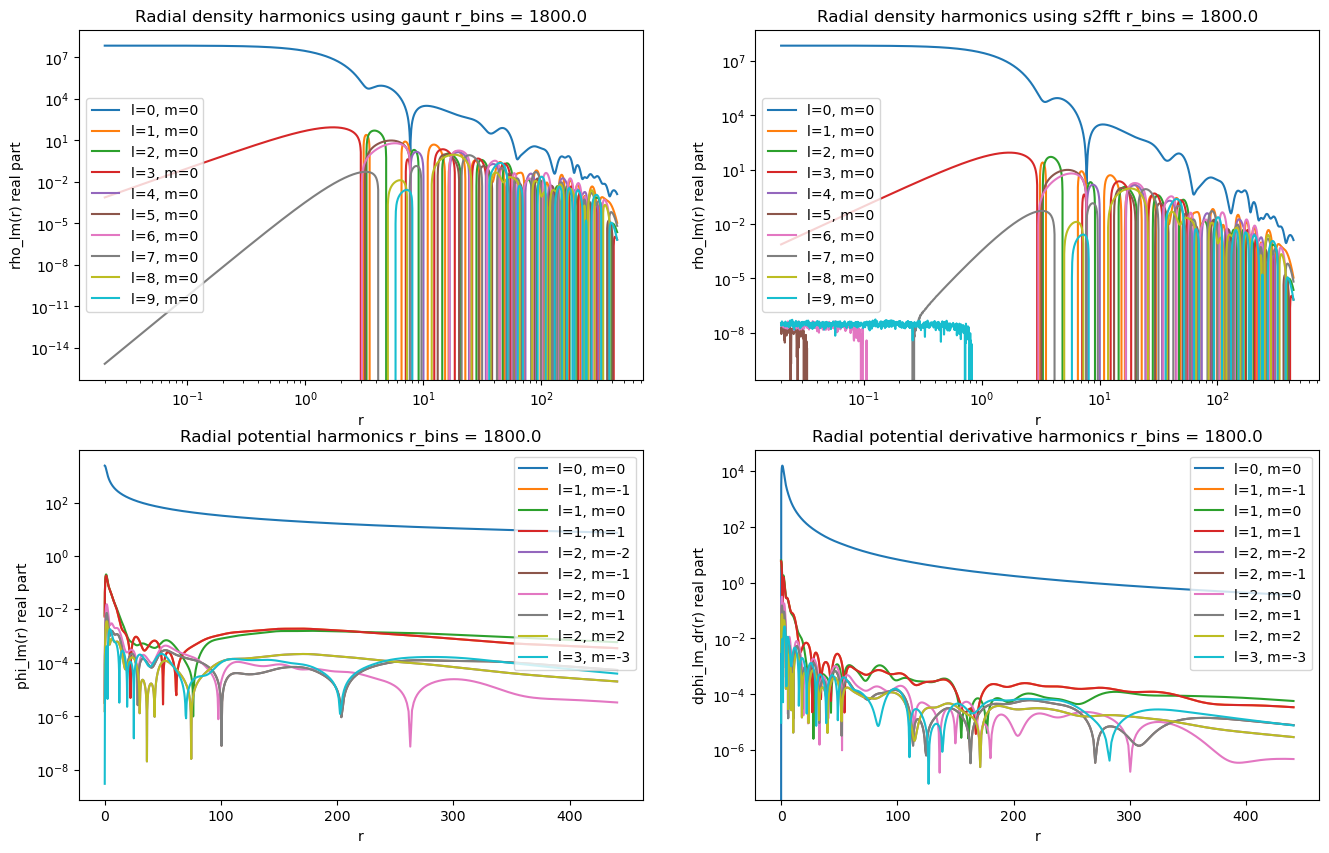

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0000%
    l=1, m=-1: max err = 0.0000%
    l=1, m=0: max err = 0.0000%
    l=1, m=1: max err = 0.0000%
    l=2, m=-2: max err = 0.0000%
    l=2, m=-1: max err = 0.0000%
    l=2, m=0: max err = 0.0000%
    l=2, m=1: max err = 0.0000%
    l=2, m=2: max err = 0.0000%
    l=3, m=-3: max err = 0.0000%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.0000%
    l=1, m=-1: max err = 0.0000%
    l=1, m=0: max err = 0.0000%
    l=1, m=1: max err = 0.0000%
    l=2, m=-2: max err = 0.0000%
    l=2, m=-1: max err = 0.0000%
    l=2, m=0: max err = 0.0000%
    l=2, m=1: max err = 0.0000%
    l=2, m=2: max err = 0.0000%
    l=3, m=-3: max err = 0.0000%


In [ ]:
no_radius_bins = np.linspace(100, 1800, 21)
print(no_radius_bins)



for no_bins in no_radius_bins:
    print(f'No. radius bins: {no_bins}')
    r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), int(no_bins))


    R_j_r_fixed = eval_library(r, eigenstate_lib.radial_eigenmode_params)  # (Nr, Nj)


    phase = jnp.exp(-1j * eigen_energies * 1 * dt / 1)
    R_j_r_phased = R_j_r_fixed * phase[None, :]

    out_lm = [(L, M) for L in range(L_max_out) for M in range(-L, L+1)]
    output_lm_pairs = jnp.array(out_lm)


    # 1. Construct total psi and rho on background grid
    rho_lms = construct_rho_lms(aj, parent_j, R_j_r_phased, lm_l, lm_m, total_mass, L_max_out, gaunt_table, scatter_matrix)

    print(rho_lms.shape)  # (Nr, L, 2L-1)

    rho_rtp = construct_rho_rtp(R_j_r_phased, aj, parent_j, Y_lm)

    rho_lms_s2fft = forward_s2fft(rho_rtp, L_max_out)



    fig, ax = plt.subplots(2, 2, figsize=(16, 10))

    for l in range(0, 10):
        ax[0, 0].plot(r * u.to_Kpc, rho_lms[:, l, L_max_out - 1].real * u.to_Msun / u.to_Kpc ** 3, label = f'l={l}, m=0')

    ax[0, 0].set_xlabel('r')
    ax[0, 0].set_ylabel('rho_lm(r) real part')
    ax[0, 0].set_title(f'Radial density harmonics using gaunt r_bins = {no_bins}')
    ax[0, 0].set_yscale('log')
    ax[0, 0].set_xscale('log')
    ax[0, 0].legend()


    for l in range(0, 10):
        ax[0, 1].plot(r * u.to_Kpc, rho_lms_s2fft[:, l, L_max_out - 1].real * u.to_Msun / u.to_Kpc ** 3, label = f'l={l}, m=0')
    ax[0, 1].set_xlabel('r')
    ax[0, 1].set_ylabel('rho_lm(r) real part')
    ax[0, 1].set_title(f'Radial density harmonics using s2fft r_bins = {no_bins}')
    ax[0, 1].set_yscale('log')
    ax[0, 1].set_xscale('log')
    ax[0, 1].legend()


    G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

    dphi_lm, phi_lm = _compute_all_phi(rho_lms, r, output_lm_pairs, int(L_max_out), G)

    for lm in range(0, 10):
        ax[1, 0].plot(r * u.to_Kpc, abs(phi_lm[lm, :].real) * u.to_kms**2, label = f'l={output_lm_pairs[lm, 0]}, m={output_lm_pairs[lm, 1]}')
    ax[1, 0].set_xlabel('r')
    ax[1, 0].set_ylabel('phi_lm(r) real part')
    ax[1, 0].set_yscale('log')
    ax[1, 0].legend()
    ax[1, 0].set_title(f'Radial potential harmonics r_bins = {no_bins}')


    for lm in range(0, 10):
        ax[1, 1].plot(r * u.to_Kpc, abs(dphi_lm[lm, :].real) * u.to_kms**2, label = f'l={output_lm_pairs[lm, 0]}, m={output_lm_pairs[lm, 1]}')
    ax[1, 1].set_xlabel('r')
    ax[1, 1].set_ylabel('dphi_lm_dr(r) real part')
    
    ax[1, 1].set_yscale('log')
    ax[1, 1].legend()
    ax[1, 1].set_title(f'Radial potential derivative harmonics r_bins = {no_bins}')
    plt.show()


    # For each (l,m) mode, interpolate phi_lm from its coarse grid onto r_truth
    # phi_lm shape: (N_lm, Nr_coarse), r shape: (Nr_coarse,)
    phi_lm_interp = jax.vmap(lambda phi_mode: jnp.interp(r_truth, r, phi_mode.real))(phi_lm) \
                + 1j * jax.vmap(lambda phi_mode: jnp.interp(r_truth, r, phi_mode.imag))(phi_lm)
    
    d_phi_lm_interp = jax.vmap(lambda dphi_mode: jnp.interp(r_truth, r, dphi_mode.real))(dphi_lm) \
                + 1j * jax.vmap(lambda dphi_mode: jnp.interp(r_truth, r, dphi_mode.imag))(dphi_lm)
    

    # Per-mode convergence for dominant modes (masking near-zero truth values)
    print(f'  phi_lm convergence (per mode):')
    for lm_idx in range(min(10, len(output_lm_pairs))):
        mask = jnp.abs(phi_lm_2000[lm_idx]) > 1e-10 * jnp.max(jnp.abs(phi_lm_2000[lm_idx]))
        err = jnp.where(mask, 100 * jnp.abs(phi_lm_interp[lm_idx] - phi_lm_2000[lm_idx]) / jnp.abs(phi_lm_2000[lm_idx]), 0.0)
        print(f'    l={output_lm_pairs[lm_idx, 0]}, m={output_lm_pairs[lm_idx, 1]}: max err = {jnp.max(err):.4f}%')

    print(f'  dphi_lm convergence (per mode):')
    for lm_idx in range(min(10, len(output_lm_pairs))):
        mask = jnp.abs(dphi_lm_2000[lm_idx]) > 1e-10 * jnp.max(jnp.abs(dphi_lm_2000[lm_idx]))
        err = jnp.where(mask, 100 * jnp.abs(d_phi_lm_interp[lm_idx] - dphi_lm_2000[lm_idx]) / jnp.abs(dphi_lm_2000[lm_idx]), 0.0)
        print(f'    l={output_lm_pairs[lm_idx, 0]}, m={output_lm_pairs[lm_idx, 1]}: max err = {jnp.max(err):.4f}%')